## 1. What this notebook computes

A spinor field (a column of 16 numbers at every point, such as the author's fields
dirac16complex and dirac16complex00) does not see the metric directly. It sees it
through a **vielbein** (a set of eight perpendicular unit directions at every point)
and through the **spin connection** (the rate at which these directions turn from
point to point). This notebook computes both, exactly, for the author's primordial
metric, and the one combination that enters the field equation,

$$\gamma^\mu \Omega_\mu = 3 H \gamma^{(x8)} .$$

It

- starts with a warm-up in two dimensions (the flat plane in polar coordinates),
  where every step can be followed by hand;
- builds the diagonal vielbein of the author's metric and checks that it gives the
  metric back;
- computes the 25 independent nonzero Christoffel symbols, the canonical spin
  connection $\omega_{\mu ab}$ (12 independent nonzero components) and the spinor
  connection $\Omega_\mu$ (16 x 16 matrices built from the author's gammas);
- checks the vielbein postulate (512 equations), the antisymmetry of $\omega$ and
  the covariant constancy of the gammas (64 matrix equations);
- computes $\gamma^\mu\Omega_\mu$ direction by direction and shows that the terms
  along the time $x4$ cancel between the three inflating directions $x1, x2, x3$
  and the three deflating extra times $x5, x6, x7$, while the six terms along the
  hidden direction $x8$ add up to $3H\gamma^{(x8)}$;
- explains why the free function $a_4(x_4)$ drops out (the divergence form);
- writes the covariant derivative and the Dirac operator out in full and compares
  all 16 component equations with the Revision record;
- repeats the computation for a NEGATIVE CONTROL, a metric whose extra times
  inflate instead of deflating: there a term $3 a_4' \gamma^{(x4)}$ survives;
- draws ten teaching plots.

Every result that the Revision record also contains is compared with the record,
and the check prints the record file and the name of its check.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 06a (Vielbein, spin connection and the term 3 H gamma^(x8) of the field
equation) is the file `Revision/textbook/notebooks/06a_spin_connection.ipynb` of the
repository Dirac_claude. Starting from the author's metric and the author's real 16 x 16
gamma matrices, it computes exactly, with sympy, the diagonal vielbein, the Christoffel
symbols, the canonical spin connection, the spinor connection Omega_mu, the covariant
derivative of a spinor and the term gamma^mu Omega_mu = 3 H gamma^(x8) of the field
equation; it shows that the time-direction terms of the three inflating and the three
deflating directions cancel, checks the result against the Revision records, repeats the
computation for a negative control with inflating extra times, works a two-dimensional
warm-up (the polar plane), and draws ten teaching plots. It needs a computer with Windows
11, macOS or Linux, an internet connection for the installation, the program Git, and
Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these packages at
exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other packages run
Jupyter, the program that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 06a_spin_connection.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 30 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 06a_spin_connection.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
06a_spin_connection.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/06a.captions.json`
- `Revision/textbook/figures/06a_1_polar_frame_and_spin_rotation.png`
- `Revision/textbook/figures/06a_2_vielbein_factors.png`
- `Revision/textbook/figures/06a_3_christoffel_pattern.png`
- `Revision/textbook/figures/06a_4_omega_heat_maps.png`
- `Revision/textbook/figures/06a_5_spinor_connection_heat_maps.png`
- `Revision/textbook/figures/06a_6_gamma_omega_per_direction.png`
- `Revision/textbook/figures/06a_7_gamma_omega_cancellation.png`
- `Revision/textbook/figures/06a_8_divergence_form.png`
- `Revision/textbook/figures/06a_9_derivative_coefficients.png`
- `Revision/textbook/figures/06a_10_negative_control.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all ten figure files exist
    ALL 34 CHECKS PASSED (notebook 06a)

and the notebook must show 10 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/06a_spin_connection.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for Revision/algebra/gammas.json or for a report: the notebook
  reads Revision records from the repository; open it inside the folder
  Revision/textbook/notebooks of a complete copy of the repository Dirac_claude (a single
  downloaded notebook file is not enough).
- a cell runs for many minutes: the exact algebra of sympy is slow on old computers; the
  whole notebook needs about a minute on a 2024 laptop. Wait, or close other programs
  that use the processor.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 06a (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 06a (Vielbein, spin connection and the term 3 H gamma^(x8) of the field
# equation) is the file Revision/textbook/notebooks/06a_spin_connection.ipynb of the
# repository Dirac_claude. Starting from the author's metric and the author's real 16 x
# 16 gamma matrices, it computes exactly, with sympy, the diagonal vielbein, the
# Christoffel symbols, the canonical spin connection, the spinor connection Omega_mu, the
# covariant derivative of a spinor and the term gamma^mu Omega_mu = 3 H gamma^(x8) of the
# field equation; it shows that the time-direction terms of the three inflating and the
# three deflating directions cancel, checks the result against the Revision records,
# repeats the computation for a negative control with inflating extra times, works a
# two-dimensional warm-up (the polar plane), and draws ten teaching plots. It needs a
# computer with Windows 11, macOS or Linux, an internet connection for the installation,
# the program Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5)
# with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0,
# matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0
# and nbconvert 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the
# other packages run Jupyter, the program that shows and runs notebooks. It does not need
# Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 06a_spin_connection.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 30
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 06a_spin_connection.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 06a_spin_connection.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/06a.captions.json
# - Revision/textbook/figures/06a_1_polar_frame_and_spin_rotation.png
# - Revision/textbook/figures/06a_2_vielbein_factors.png
# - Revision/textbook/figures/06a_3_christoffel_pattern.png
# - Revision/textbook/figures/06a_4_omega_heat_maps.png
# - Revision/textbook/figures/06a_5_spinor_connection_heat_maps.png
# - Revision/textbook/figures/06a_6_gamma_omega_per_direction.png
# - Revision/textbook/figures/06a_7_gamma_omega_cancellation.png
# - Revision/textbook/figures/06a_8_divergence_form.png
# - Revision/textbook/figures/06a_9_derivative_coefficients.png
# - Revision/textbook/figures/06a_10_negative_control.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all ten figure files exist
#     ALL 34 CHECKS PASSED (notebook 06a)
#
# and the notebook must show 10 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/06a_spin_connection.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for Revision/algebra/gammas.json or for a report: the notebook
#   reads Revision records from the repository; open it inside the folder
#   Revision/textbook/notebooks of a complete copy of the repository Dirac_claude (a
#   single downloaded notebook file is not enough).
# - a cell runs for many minutes: the exact algebra of sympy is slow on old computers;
#   the whole notebook needs about a minute on a 2024 laptop. Wait, or close other
#   programs that use the processor.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "06a"  # this notebook: chapter 06, example a


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 06a complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Coordinates** $x1, \dots, x8$: the eight numbers that name a point, with the
  author's names: $x1, x2, x3$ ordinary 3-space; $x4$ the time; $x5, x6, x7$ the
  three **extra times**; $x8$ the **hidden direction**. In Python lists they have
  the positions 0 to 7 (Python counts from 0), so `x[3]` is $x4$ and `x[7]` is
  $x8$.
- **Metric** $g_{\mu\nu}$: the rule that turns small coordinate steps into squared
  lengths, $ds^2 = \sum_\mu g_{\mu\mu} (dx^\mu)^2$ for the author's (diagonal)
  metric. A positive $g_{\mu\mu}$ makes direction $\mu$ **space-like**, a negative
  one **time-like**.
- **Signature (4,4)**: four space-like directions ($x1, x2, x3, x8$) and four
  time-like ones ($x4, x5, x6, x7$).
- **Frame metric** $\eta_{ab}$: the constant diagonal matrix
  $\mathrm{diag}(+1,+1,+1,-1,-1,-1,-1,+1)$ in the order $x1, \dots, x8$.
- **Vielbein** $e^a{}_\mu$ (German "many legs"): at every point eight directions
  that are perpendicular and of unit length, so that
  $g_{\mu\nu} = \sum_{a} \eta_{aa} e^a{}_\mu e^a{}_\nu$. The index $a$ (a
  **frame index**) numbers the eight directions; $\mu$ (a **coordinate index**)
  numbers the coordinates. Its **inverse** $e_a{}^\mu$ satisfies
  $\sum_\mu e^a{}_\mu e_b{}^\mu = \delta^a_b$ (1 if $a = b$, else 0).
- **Christoffel symbols** $\Gamma^\lambda{}_{\mu\nu}$: the numbers that say how the
  coordinate directions change from point to point; computed from the first
  derivatives of the metric.
- **Spin connection** $\omega_\mu{}^a{}_b$: the numbers that say how the vielbein
  turns when one moves along $x^\mu$. The **canonical** one is fixed by the
  **vielbein postulate** (below). Lowering the first frame index with $\eta$ gives
  $\omega_{\mu ab} = \eta_{aa}\,\omega_\mu{}^a{}_b$, which is **antisymmetric**:
  $\omega_{\mu ab} = -\omega_{\mu ba}$.
- **Gamma matrices** $\gamma^a$: the author's eight real 16 x 16 matrices with
  $\gamma^a\gamma^b + \gamma^b\gamma^a = 2\eta^{ab}\,1$ (the **Clifford
  relation**; $1$ is the 16 x 16 identity matrix). **Curved gammas**:
  $\gamma^\mu = \sum_a e_a{}^\mu \gamma^a$.
- **Commutator** $[A, B] = AB - BA$; **anticommutator** $\{A, B\} = AB + BA$.
- $S^{ab} = \frac14[\gamma^a, \gamma^b]$: the 28 matrices (one for each pair
  $a < b$) that turn spinors when the frame is turned.
- **Spinor connection** $\Omega_\mu = \frac12 \sum_{a,b}\omega_{\mu ab} S^{ab}$: a
  16 x 16 matrix for every $\mu$.
- **Covariant derivative** of a spinor: $D_\mu \Psi = \partial_\mu \Psi +
  \Omega_\mu \Psi$ ($\partial_\mu$ is the partial derivative with respect to
  $x^\mu$). **Dirac operator**: $\gamma^\mu D_\mu = \sum_\mu \gamma^\mu D_\mu$.
- **Trace** $\mathrm{tr}\,M$: the sum of the diagonal entries of a square matrix.
- **Exact** computation: with symbols and fractions (sympy), not with rounded
  decimal numbers; an exact check that an expression is zero proves it for ALL
  values of the symbols.
- **Negative control**: a deliberately changed case in which the effect must NOT
  occur (or must occur differently); it shows that a check can fail and that the
  result depends on the feature that was changed.
- **Heat map**: a picture of a matrix in which every entry is a small coloured
  square; here red is positive, blue is negative and white is zero.

## 4. The physical and mathematical situation

**The author's metric.** With $z = 6 H x_8$ in the interval $(0, \pi/2)$, a positive
constant $H$ and a function $a_4(x_4)$ of the time,

$$g = \mathrm{diag}\big(e^{2a_4}\sin^{1/3}z,\ e^{2a_4}\sin^{1/3}z,\
e^{2a_4}\sin^{1/3}z,\ -1,\ -e^{-2a_4}\sin^{1/3}z,\ -e^{-2a_4}\sin^{1/3}z,\
-e^{-2a_4}\sin^{1/3}z,\ \cot^2 z\big).$$

When $a_4$ grows, lengths along $x1, x2, x3$ grow like $e^{a_4}$ (3-space
**inflates**) and lengths along the extra times $x5, x6, x7$ shrink like
$e^{-a_4}$ (the extra times **deflate exponentially**).

**The diagonal vielbein.** Because $g$ is diagonal, the vielbein can be chosen
diagonal: $e^a{}_\mu = f_a\,\delta^a_\mu$ with $f_a = \sqrt{|g_{aa}|}$:

$$f = \big(e^{a_4}s,\ e^{a_4}s,\ e^{a_4}s,\ 1,\ e^{-a_4}s,\ e^{-a_4}s,\
e^{-a_4}s,\ \cot z\big), \qquad s = \sin^{1/6} z .$$

**The formulas used** (the standard ones of general relativity with spinors):

$$\Gamma^\lambda{}_{\mu\nu} = \tfrac12 \sum_\rho g^{\lambda\rho}\big(\partial_\mu
g_{\rho\nu} + \partial_\nu g_{\rho\mu} - \partial_\rho g_{\mu\nu}\big),$$

$$\omega_\mu{}^a{}_b = \sum_\nu e^a{}_\nu \Big(\partial_\mu e_b{}^\nu +
\sum_\lambda \Gamma^\nu{}_{\mu\lambda} e_b{}^\lambda\Big), \qquad
\omega_{\mu ab} = \eta_{aa}\,\omega_\mu{}^a{}_b ,$$

$$\Omega_\mu = \tfrac12 \sum_{a,b} \omega_{\mu ab} S^{ab}, \qquad D_\mu\Psi =
\partial_\mu\Psi + \Omega_\mu\Psi, \qquad \gamma^\mu = \sum_a e_a{}^\mu\gamma^a .$$

The formula for $\omega$ is the unique solution of the **vielbein postulate**
$\partial_\mu e^a{}_\nu - \sum_\lambda \Gamma^\lambda{}_{\mu\nu} e^a{}_\lambda +
\sum_b \omega_\mu{}^a{}_b e^b{}_\nu = 0$: the vielbein is constant for the full
covariant derivative. The notebook checks this equation in all 512 components.

**What is PROVED here (exact, sympy) and what it means.** In the diagonal vielbein,
$\gamma^\mu\Omega_\mu = 3H\gamma^{(x8)}$ for every $H > 0$ and every function
$a_4(x_4)$. This term appears in the field equation $\gamma^\mu D_\mu\Psi =
(m + U'(S))\Psi$ of both fields. Its value belongs to the diagonal vielbein: the
next notebook of this chapter (06b) shows that in another vielbein of the same
metric the contraction changes, and even vanishes, and that a rescaling of the
field removes it. What no choice can remove is the curvature of the metric.

## 5. The tools: sympy and the author's gamma matrices

The next cell imports numpy (numbers for the plots) and sympy (exact algebra),
reads the author's eight gamma matrices from the Revision record
`Revision/algebra/gammas.json`, and checks two of their properties: the 64
Clifford relations and that every entry is a real number. It then builds the 28
matrices $S^{ab} = \frac14[\gamma^a, \gamma^b]$.

In [2]:
import numpy as np  # arrays of decimal numbers (only for the plots)
import sympy as sp  # exact algebra and calculus with symbols

GAMMA_FILE = "Revision/algebra/gammas.json"  # a Revision record (read only)
fixture = json.loads(repository_file(GAMMA_FILE).read_text(encoding="utf-8"))
NAMES = fixture["coordinates"]  # ["x1", ..., "x8"], the names of the directions
ETA = fixture["eta"]  # the frame metric: +1 space-like, -1 time-like
# Each gamma is stored as 16 rows of 16 whole numbers; sp.Matrix makes it an exact
# sympy matrix.  gamma[a] is the gamma of the direction NAMES[a].
gamma = [sp.Matrix(rows) for rows in fixture["gamma"]]
I16 = sp.eye(16)  # the 16 x 16 identity matrix
Z16 = sp.zeros(16, 16)  # the 16 x 16 zero matrix
say(f"directions: {NAMES}")
say(f"eta (frame metric): {ETA}")
# The Clifford relation for all 8 x 8 = 64 pairs (a, b): the anticommutator is
# 2 eta_aa times the identity when a = b and the zero matrix when a and b differ.
clifford = all(gamma[a] * gamma[b] + gamma[b] * gamma[a]
               == (2 * ETA[a] if a == b else 0) * I16
               for a in range(8) for b in range(8))
check(clifford, "the 64 Clifford relations of the author's gammas",
      record="Revision/theory/reports/python-field-theory.json, "
             "check clifford_relations")
check(all(entry.is_real for matrix in gamma for entry in matrix),
      "every entry of every gamma is a real number",
      record="Revision/theory/reports/python-field-theory.json, check gammas_real")
# S[a][b] = (1/4)(gamma^a gamma^b - gamma^b gamma^a), for all 64 pairs (a, b).
S = [[(gamma[a] * gamma[b] - gamma[b] * gamma[a]) / 4 for b in range(8)]
     for a in range(8)]

directions: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8']
eta (frame metric): [1, 1, 1, -1, -1, -1, -1, 1]
PASS the 64 Clifford relations of the author's gammas
     reproduces Revision/theory/reports/python-field-theory.json, check
    clifford_relations
PASS every entry of every gamma is a real number
     reproduces Revision/theory/reports/python-field-theory.json, check gammas_real


The next cell defines four small helpers that the rest of the notebook uses.

- `is_zero(expr)` decides EXACTLY whether a sympy expression is zero for all values
  of its symbols. It first tries a fast route (write every sine and cosine through
  exponential functions, multiply out, cancel common factors) and then sympy's
  general `simplify`. It never says "zero" for an expression that is not zero; at
  worst it fails to recognise a zero, and then a check fails visibly.
- `matrix_is_zero(M)` applies `is_zero` to every entry of a matrix.
- `record_passed(path, name)` opens a Revision report (a JSON file) and returns
  True when the report records the check `name` as passed.
- `record_formula(key)` reads a formula of the record
  `Revision/theory/field-theory.json`, which is written in the notation of the
  Wolfram Language, and turns it into a sympy expression with sympy's reader
  `parse_mathematica`.

In [3]:
from sympy.parsing.mathematica import parse_mathematica  # reads Wolfram notation


def is_zero(expr):
    """True when expr is exactly zero for all values of its symbols."""
    expr = sp.sympify(expr)
    if expr == 0:
        return True
    # Fast route: sin, cos, tan, ... written through exp, multiplied out, cancelled.
    if sp.cancel(sp.expand(expr.rewrite(sp.exp))) == 0:
        return True
    return sp.simplify(expr) == 0  # the slower general route


def matrix_is_zero(matrix):
    """True when every entry of the matrix is exactly zero."""
    return all(is_zero(entry) for entry in matrix)


def record_passed(path, name):
    """True when the Revision report at path records the check name as passed."""
    data = json.loads(repository_file(path).read_text(encoding="utf-8"))
    for entry in data["checks"]:
        if entry["name"] == name:
            return entry["verdict"].upper() == "PASS"  # "PASS" or "pass"
    raise KeyError(f"{path} has no check {name}")


THEORY_FILE = "Revision/theory/field-theory.json"  # the record of the formulas
FORMULAS = {item["key"]: item["wl"] for item in json.loads(
    repository_file(THEORY_FILE).read_text(encoding="utf-8"))["formulas"]}


def record_formula(key, names):
    """The formula key of the record as a sympy expression.  names maps the
    record's symbol names (texts) to the symbols and functions of this notebook."""
    text = FORMULAS[key]
    # The record writes a4', a4'' and a4(x4) as Derivative[1][a4][x4],
    # Derivative[2][a4][x4] and a4[x4]; give them short names before reading.
    for long_form, short_form in (("Derivative[1][a4][x4]", "a4p"),
                                  ("Derivative[2][a4][x4]", "a4pp"),
                                  ("a4[x4]", "a4")):
        text = text.replace(long_form, short_form)
    expr = parse_mathematica(text)
    return expr.subs({sp.Symbol(name): value for name, value in names.items()},
                     simultaneous=True)


REPORT_PY = "Revision/theory/reports/python-field-theory.json"
REPORT_WL = "Revision/theory/reports/wolfram-field-theory.json"
REPORT_LEAD = "Revision/lead_checks/reports/emt-divergence-and-spin-connection.json"
say(f"{len(FORMULAS)} formulas read from {THEORY_FILE}")

32 formulas read from Revision/theory/field-theory.json


## 6. Four general formulas as Python functions

The next cell turns the formulas of Section 4 into four Python functions. They work
in ANY number of dimensions and for ANY vielbein, so the same functions serve the
two-dimensional warm-up and the author's eight-dimensional metric.

- `christoffel(g, coords)`: the Christoffel symbols of the metric matrix `g`;
  `Gam[l][m][n]` is $\Gamma^l{}_{mn}$. Because $\Gamma^l{}_{mn} = \Gamma^l{}_{nm}$,
  each pair $(m, n)$ is computed once.
- `spin_connection(e, Gam, coords, eta)`: the canonical spin connection with the
  first frame index lowered, `omega[mu][a][b]` $= \omega_{\mu ab}$. The vielbein is
  the matrix `e` with `e[a, mu]` $= e^a{}_\mu$ (row = frame index, column =
  coordinate index); its inverse matrix `E = e.inv()` has `E[mu, a]` $=
  e_a{}^\mu$, because $\sum_\mu e^a{}_\mu e_b{}^\mu = \delta^a_b$ says exactly
  `e * E = 1`.
- `spinor_connection(omega, S)`: $\Omega_\mu = \frac12\sum_{a,b}\omega_{\mu ab}
  S^{ab}$. Since both $\omega_{\mu ab}$ and $S^{ab}$ change sign when $a$ and $b$
  are exchanged, the terms $(a, b)$ and $(b, a)$ are equal, and the factor
  $\frac12$ is used up by summing over $a < b$ only.
- `curved_gammas(e, gammas)`: $\gamma^\mu = \sum_a e_a{}^\mu \gamma^a$.

Every nonzero result is simplified with sympy's `simplify`, so that it prints in a
short form.

In [4]:
def christoffel(g, coords):
    """Gam[l][m][n] = (1/2) sum_r g^lr (d_m g_rn + d_n g_rm - d_r g_mn)."""
    n = len(coords)
    g_inv = g.inv()  # the inverse metric g^lr
    Gam = [[[sp.Integer(0)] * n for _ in range(n)] for _ in range(n)]
    for l in range(n):
        for m in range(n):
            for k in range(m, n):  # Gamma^l_mk = Gamma^l_km: compute it once
                value = sum(g_inv[l, r] * (sp.diff(g[r, k], coords[m])
                                           + sp.diff(g[r, m], coords[k])
                                           - sp.diff(g[m, k], coords[r]))
                            for r in range(n) if g_inv[l, r] != 0) / 2
                value = sp.simplify(value)
                Gam[l][m][k] = value
                Gam[l][k][m] = value
    return Gam


def spin_connection(e, Gam, coords, eta):
    """omega[mu][a][b] = omega_{mu ab} = eta_aa omega_mu^a_b, where
    omega_mu^a_b = sum_nu e^a_nu (d_mu e_b^nu + sum_lam Gam^nu_{mu lam} e_b^lam)."""
    n = len(coords)
    E = e.inv()  # E[nu, b] = e_b^nu, the inverse vielbein
    omega = [[[sp.Integer(0)] * n for _ in range(n)] for _ in range(n)]
    for mu in range(n):
        for a in range(n):
            for b in range(n):
                mixed = 0  # will become omega_mu^a_b
                for nu in range(n):
                    if e[a, nu] == 0:
                        continue  # this term is zero
                    inner = sp.diff(E[nu, b], coords[mu]) + sum(
                        Gam[nu][mu][lam] * E[lam, b] for lam in range(n))
                    mixed += e[a, nu] * inner
                omega[mu][a][b] = sp.simplify(eta[a] * mixed)  # lower the index a
    return omega


def spinor_connection(omega, S):
    """Omega[mu] = (1/2) sum_{a,b} omega_{mu ab} S^ab = sum_{a<b} omega_{mu ab} S^ab."""
    n = len(omega)
    size = S[0][0].shape[0]  # 16 for the author's gammas, 2 in two dimensions
    Omega = []
    for mu in range(n):
        total = sp.zeros(size, size)
        for a in range(n):
            for b in range(a + 1, n):
                if omega[mu][a][b] != 0:
                    total += omega[mu][a][b] * S[a][b]
        Omega.append(total)
    return Omega


def curved_gammas(e, gammas):
    """gamma^mu = sum_a e_a^mu gamma^a for every coordinate mu."""
    E = e.inv()
    n = len(gammas)
    return [sum((E[mu, a] * gammas[a] for a in range(n)),
                sp.zeros(*gammas[0].shape)) for mu in range(n)]


say("defined: christoffel, spin_connection, spinor_connection, curved_gammas")

defined: christoffel, spin_connection, spinor_connection, curved_gammas


## 7. A warm-up in two dimensions: the flat plane in polar coordinates

Before eight dimensions, two. A point of the flat plane has the polar coordinates
$r$ (distance from the centre) and $\varphi$ (angle). The metric is
$ds^2 = dr^2 + r^2 d\varphi^2$, so $g = \mathrm{diag}(1, r^2)$ and $\eta =
\mathrm{diag}(1, 1)$. The unit directions are the radial direction (frame index 0)
and the angular direction (frame index 1); a step $d\varphi$ has the length
$r\,d\varphi$, so the vielbein is $e = \mathrm{diag}(1, r)$. Two 2 x 2 matrices with
the Clifford relation of the plane are the Pauli matrices $\sigma_1$ and
$\sigma_2$, so $\gamma^0 = \sigma_1$ and $\gamma^1 = \sigma_2$.

The next cell computes everything with the general functions and checks the
results that can be worked by hand:
$\Gamma^r{}_{\varphi\varphi} = -r$, $\Gamma^\varphi{}_{r\varphi} = 1/r$;
$\omega_{\varphi 01} = -1$ (the frame turns by one radian per radian of
$\varphi$); $\Omega_\varphi = -\frac{i}{2}\sigma_3$; and
$\gamma^\mu\Omega_\mu = \sigma_1/(2r)$, so that the Dirac operator of the plane in
polar coordinates is $\sigma_1(\partial_r + \frac{1}{2r}) + \frac{\sigma_2}{r}
\partial_\varphi$. The plane is flat, so the curvature of the spinor connection,
$F_{r\varphi} = \partial_r\Omega_\varphi - \partial_\varphi\Omega_r +
[\Omega_r, \Omega_\varphi]$, must vanish; the cell checks that too, and that
$\Omega_\varphi = -(\partial_\varphi U)U^{-1}$ for the spinor rotation
$U(\varphi) = \cos\frac{\varphi}{2} + i\sin\frac{\varphi}{2}\,\sigma_3$: in a flat
space the spin connection is only the turning of the chosen frame and can be
undone.

In [5]:
r, phi = sp.symbols("r phi", positive=True)  # polar coordinates, r > 0
sigma1 = sp.Matrix([[0, 1], [1, 0]])  # the three Pauli matrices
sigma2 = sp.Matrix([[0, -sp.I], [sp.I, 0]])
sigma3 = sp.Matrix([[1, 0], [0, -1]])
plane_gammas = [sigma1, sigma2]  # gamma^0 (radial), gamma^1 (angular)
plane_eta = [1, 1]
plane_S = [[(plane_gammas[a] * plane_gammas[b] - plane_gammas[b] * plane_gammas[a])
            / 4 for b in range(2)] for a in range(2)]
plane_g = sp.diag(1, r**2)  # ds^2 = dr^2 + r^2 dphi^2
plane_e = sp.diag(1, r)  # e^a_mu: unit radial and unit angular direction

plane_Gam = christoffel(plane_g, [r, phi])
plane_omega = spin_connection(plane_e, plane_Gam, [r, phi], plane_eta)
plane_Omega = spinor_connection(plane_omega, plane_S)
plane_gup = curved_gammas(plane_e, plane_gammas)
plane_slash = sp.simplify(plane_gup[0] * plane_Omega[0] + plane_gup[1] * plane_Omega[1])
say(f"Gamma^r_phiphi = {plane_Gam[0][1][1]},  Gamma^phi_rphi = {plane_Gam[1][0][1]}")
say(f"omega_phi01 = {plane_omega[1][0][1]},  omega_phi10 = {plane_omega[1][1][0]}")
say(f"Omega_phi = {plane_Omega[1].tolist()}")
say(f"gamma^mu Omega_mu = {plane_slash.tolist()}")
check(plane_Gam[0][1][1] == -r and plane_Gam[1][0][1] == 1 / r,
      "polar plane: Gamma^r_phiphi = -r and Gamma^phi_rphi = 1/r")
check(plane_omega[1][0][1] == -1 and plane_omega[1][1][0] == 1
      and plane_omega[0][0][1] == 0, "polar plane: omega_phi01 = -1, omega_r = 0")
check(plane_Omega[1] == -sp.I / 2 * sigma3 and plane_Omega[0] == sp.zeros(2, 2),
      "polar plane: Omega_phi = -(i/2) sigma3 and Omega_r = 0")
check(plane_slash == sigma1 / (2 * r), "polar plane: gamma^mu Omega_mu = sigma1/(2 r)")
F_rphi = (plane_Omega[1].diff(r) - plane_Omega[0].diff(phi)
          + plane_Omega[0] * plane_Omega[1] - plane_Omega[1] * plane_Omega[0])
U = sp.cos(phi / 2) * sp.eye(2) + sp.I * sp.sin(phi / 2) * sigma3  # spinor rotation
pure_gauge = -U.diff(phi) * U.inv() - plane_Omega[1]  # must be the zero matrix
check(F_rphi == sp.zeros(2, 2) and matrix_is_zero(pure_gauge),
      "polar plane: flat (F_rphi = 0) and Omega_phi = -(dU/dphi) U^-1")

Gamma^r_phiphi = -r,  Gamma^phi_rphi = 1/r
omega_phi01 = -1,  omega_phi10 = 1
Omega_phi = [[-I/2, 0], [0, I/2]]
gamma^mu Omega_mu = [[0, 1/(2*r)], [1/(2*r), 0]]
PASS polar plane: Gamma^r_phiphi = -r and Gamma^phi_rphi = 1/r
PASS polar plane: omega_phi01 = -1, omega_r = 0
PASS polar plane: Omega_phi = -(i/2) sigma3 and Omega_r = 0
PASS polar plane: gamma^mu Omega_mu = sigma1/(2 r)
PASS polar plane: flat (F_rphi = 0) and Omega_phi = -(dU/dphi) U^-1


The next cell draws two pictures of the warm-up. On the left, the unit radial
direction (black arrows) and the unit angular direction (orange arrows) at twelve
angles on two circles: the frame turns as one goes around, by exactly the angle
$\varphi$, which is why $\omega_{\varphi 01} = -1$ (one radian of frame rotation per
radian of $\varphi$; the sign records the sense of rotation). On the right, the two
nonzero entries of the spinor rotation $U(\varphi)$ that undoes this turning, for
$\varphi$ from $0$ to $4\pi$: after one full turn ($\varphi = 2\pi$) $U = -1$, and
only after two full turns is $U = +1$ again. A spinor turns by half the angle of the
frame; this is the "double cover" of rotations by spinor transformations.

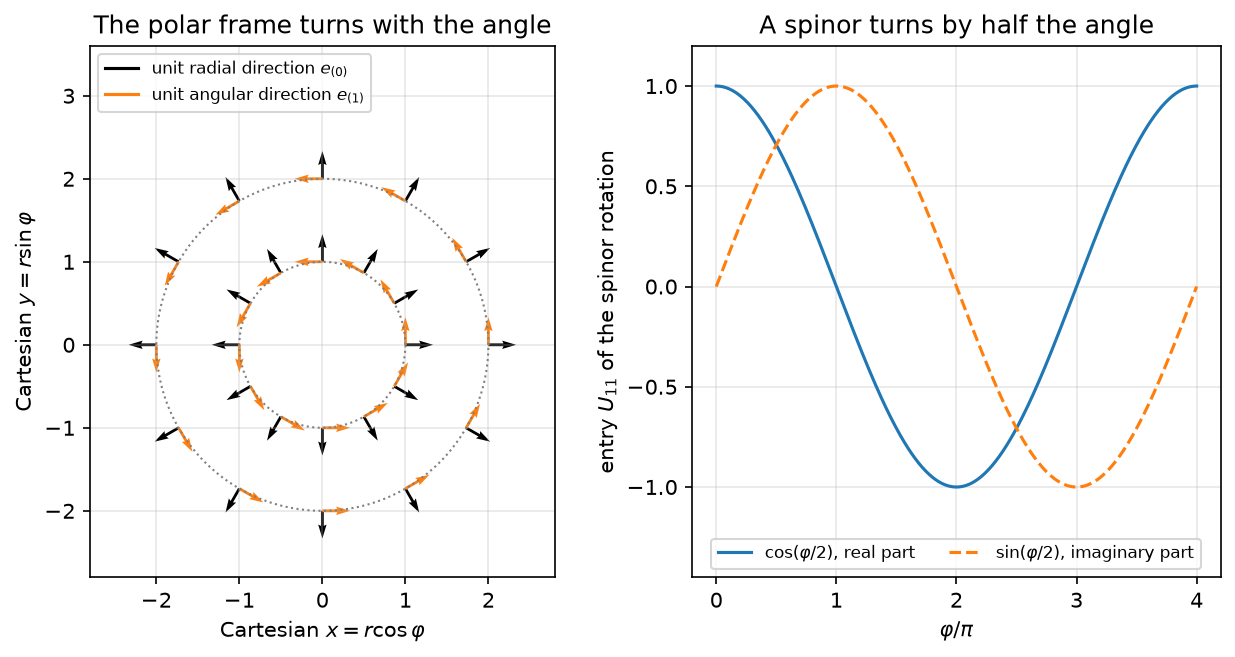

Figure 06a.1 saved as Revision/textbook/figures/06a_1_polar_frame_and_spin_rotation.png


In [6]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(10.0, 4.6))
angles = np.arange(12) * np.pi / 6  # 12 angles, 30 degrees apart
for radius in (1.0, 2.0):
    px, py = radius * np.cos(angles), radius * np.sin(angles)  # the points
    ax_left.quiver(px, py, np.cos(angles), np.sin(angles), color="black",
                   angles="xy", scale_units="xy", scale=3.0, width=0.006)
    ax_left.quiver(px, py, -np.sin(angles), np.cos(angles), color="tab:orange",
                   angles="xy", scale_units="xy", scale=3.0, width=0.006)
    circle = np.linspace(0.0, 2.0 * np.pi, 200)
    ax_left.plot(radius * np.cos(circle), radius * np.sin(circle), ":",
                 color="gray", linewidth=1.0)
ax_left.plot([], [], color="black", label="unit radial direction $e_{(0)}$")
ax_left.plot([], [], color="tab:orange", label="unit angular direction $e_{(1)}$")
ax_left.set_aspect("equal")
ax_left.set_xlim(-2.8, 2.8)
ax_left.set_ylim(-2.8, 3.6)  # room for the legend above the circles
ax_left.set_xlabel("Cartesian $x = r\\cos\\varphi$")
ax_left.set_ylabel("Cartesian $y = r\\sin\\varphi$")
ax_left.set_title("The polar frame turns with the angle")
ax_left.legend(loc="upper left", fontsize=8)
turn = np.linspace(0.0, 4.0 * np.pi, 400)  # phi from 0 to 4 pi
ax_right.plot(turn / np.pi, np.cos(turn / 2), label="$\\cos(\\varphi/2)$, real part")
ax_right.plot(turn / np.pi, np.sin(turn / 2), "--",
              label="$\\sin(\\varphi/2)$, imaginary part")
ax_right.set_xlabel("$\\varphi / \\pi$")
ax_right.set_ylabel("entry $U_{11}$ of the spinor rotation")
ax_right.set_ylim(-1.45, 1.2)  # room for the legend below the curves
ax_right.set_title("A spinor turns by half the angle")
ax_right.legend(loc="lower center", ncol=2, fontsize=8)
save_figure(fig, "polar_frame_and_spin_rotation",
            "Warm-up in the flat plane. Left: the unit radial direction (black) and "
            "the unit angular direction (orange) of the polar frame at twelve angles "
            "on the circles $r = 1$ and $r = 2$, drawn in Cartesian coordinates $x$, "
            "$y$ (pure numbers); the frame turns by the angle $\\varphi$ as one goes "
            "around, and the spin connection $\\omega_{\\varphi 01} = -1$ records "
            "this rate. Right: the entry $U_{11} = \\cos(\\varphi/2) + "
            "i\\sin(\\varphi/2)$ of the spinor rotation that undoes the turning, real "
            "part (solid) and imaginary part (dashed), for $\\varphi$ from $0$ to "
            "$4\\pi$; at $\\varphi = 2\\pi$ the spinor rotation is $-1$, and only at "
            "$4\\pi$ is it $+1$ again.")

## 8. The author's metric and its diagonal vielbein

The next cell makes the symbols of the author's metric: the coordinates $x1, \dots,
x8$ (real), the constant $H > 0$, the function $a_4(x_4)$ (an unknown function:
every result below holds for EVERY $a_4$), and $z = 6Hx_8$. It writes the eight
factors $f_a$ of the diagonal vielbein and checks three things: that
$\eta_{aa} f_a^2 = g_{aa}$ reproduces the author's metric as recorded in
`Revision/theory/field-theory.json` (key `metric`); that the factors equal the
record's `vielbein_diagonal`; and that $\sqrt{|\det g|} = f_1 f_2 \cdots f_8 =
\cos z$. The last fact has a meaning: the factors $e^{3a_4}$ of the inflating
3-space and $e^{-3a_4}$ of the deflating extra times cancel in the volume, so the
7-volume of a slice does not change with the time $x4$.

In [7]:
x = sp.symbols("x1:9", real=True)  # x[0] = x1, ..., x[3] = x4, ..., x[7] = x8
x4, x8 = x[3], x[7]
H = sp.Symbol("H", positive=True)  # the author's constant H > 0
a4 = sp.Function("a4")(x4)  # the metric function a4(x4): any function of the time
z = 6 * H * x8  # the hidden angle z = 6 H x8, between 0 and pi/2
s = sp.sin(z) ** sp.Rational(1, 6)  # sin^(1/6) z
f = [sp.exp(a4) * s] * 3 + [sp.Integer(1)] + [sp.exp(-a4) * s] * 3 + [sp.cot(z)]
g = sp.diag(*[ETA[a] * f[a] ** 2 for a in range(8)])  # g_aa = eta_aa f_a^2
e = sp.diag(*f)  # the diagonal vielbein e^a_mu = f_a delta^a_mu
# The names under which the record writes symbols, and our symbols for them:
RECORD_NAMES = {"H": H, "x4": x4, "x8": x8, "a4": a4,
                "a4p": sp.Derivative(a4, x4), "a4pp": sp.Derivative(a4, (x4, 2))}
metric_record = sp.Matrix([list(row) for row in record_formula("metric", RECORD_NAMES)])
f_record = record_formula("vielbein_diagonal", RECORD_NAMES)
check(matrix_is_zero(g - metric_record),
      "eta_aa f_a^2 is the author's metric (all 64 entries)",
      record=f"{THEORY_FILE}, formula metric")
check(all(is_zero(f[a] - f_record[a]) for a in range(8))
      and record_passed(REPORT_LEAD, "vielbein_reproduces_metric"),
      "the eight vielbein factors f_a",
      record=f"{THEORY_FILE}, formula vielbein_diagonal")
volume = sp.simplify(sp.prod(f))  # f1 f2 ... f8
say(f"f1 f2 ... f8 = {volume}")
check(is_zero(volume - sp.cos(z)) and is_zero(volume**2 - g.det()),
      "sqrt|det g| = f1 f2 ... f8 = cos z, independent of x4",
      record=f"{REPORT_PY}, check sqrt_det_g_equals_cos_z")

PASS eta_aa f_a^2 is the author's metric (all 64 entries)
     reproduces Revision/theory/field-theory.json, formula metric
PASS the eight vielbein factors f_a
     reproduces Revision/theory/field-theory.json, formula vielbein_diagonal
f1 f2 ... f8 = cos(6*H*x8)
PASS sqrt|det g| = f1 f2 ... f8 = cos z, independent of x4
     reproduces Revision/theory/reports/python-field-theory.json, check
    sqrt_det_g_equals_cos_z


The next cell draws the eight vielbein factors. The left panel shows how they
depend on the time $x4$ at the fixed hidden angle $z = \pi/4$, for one illustrative
history $a_4(x_4) = x_4$ in units in which $H = 1$ (an illustration only: the
results of this notebook hold for every $a_4$). On a logarithmic vertical axis the
exponential factors are straight lines: the 3-space factor $e^{a_4}s$ rises, the
extra-time factor $e^{-a_4}s$ falls at the same rate, and their product is
constant. The right panel shows the dependence on $z$ at $x_4 = 0$: the factor
$s = \sin^{1/6} z$ of the six warped directions, the hidden-direction factor
$\cot z$ and the volume factor $\sqrt{|\det g|} = \cos z$.

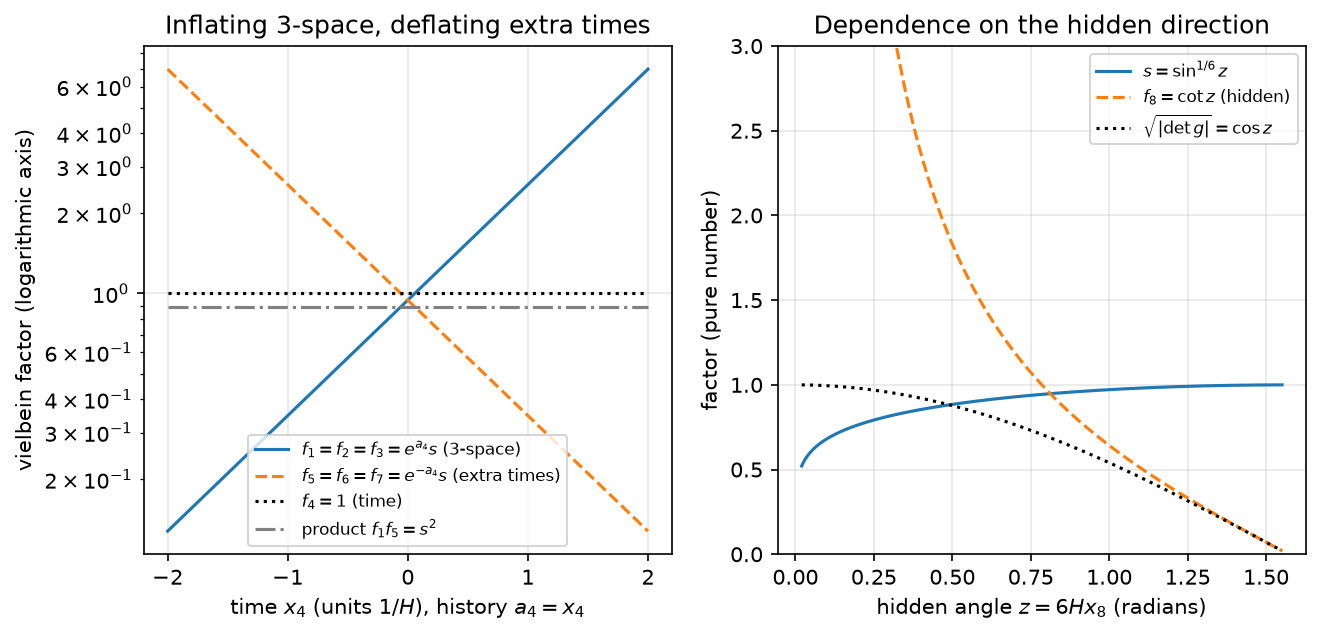

Figure 06a.2 saved as Revision/textbook/figures/06a_2_vielbein_factors.png


In [8]:
X4_SYMBOL = sp.Symbol("t", real=True)  # the time x4 as a plain symbol for numbers
history = {a4: X4_SYMBOL}  # the illustrative history a4(x4) = x4 (with H = 1)
f_of_time = sp.lambdify(X4_SYMBOL, [fa.subs(history).subs({H: 1, x8: sp.pi / 24})
                                    for fa in f])  # z = 6 x8 = pi/4
times = np.linspace(-2.0, 2.0, 201)
values = [np.broadcast_to(v, times.shape) for v in f_of_time(times)]
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(10.0, 4.4))
ax_left.semilogy(times, values[0], label="$f_1 = f_2 = f_3 = e^{a_4}s$ (3-space)")
ax_left.semilogy(times, values[4], "--",
                 label="$f_5 = f_6 = f_7 = e^{-a_4}s$ (extra times)")
ax_left.semilogy(times, values[3], ":", color="black", label="$f_4 = 1$ (time)")
ax_left.semilogy(times, values[0] * values[4], "-.", color="gray",
                 label="product $f_1 f_5 = s^2$")
ax_left.set_xlabel("time $x_4$ (units $1/H$), history $a_4 = x_4$")
ax_left.set_ylabel("vielbein factor (logarithmic axis)")
ax_left.set_title("Inflating 3-space, deflating extra times")
ax_left.legend(fontsize=8)
zz = np.linspace(0.02, np.pi / 2 - 0.02, 300)  # z inside (0, pi/2)
ax_right.plot(zz, np.sin(zz) ** (1 / 6), label="$s = \\sin^{1/6} z$")
ax_right.plot(zz, 1 / np.tan(zz), "--", label="$f_8 = \\cot z$ (hidden)")
ax_right.plot(zz, np.cos(zz), ":", color="black",
              label="$\\sqrt{|\\det g|} = \\cos z$")
ax_right.set_ylim(0.0, 3.0)
ax_right.set_xlabel("hidden angle $z = 6 H x_8$ (radians)")
ax_right.set_ylabel("factor (pure number)")
ax_right.set_title("Dependence on the hidden direction")
ax_right.legend(fontsize=8)
save_figure(fig, "vielbein_factors",
            "The eight factors $f_a$ of the diagonal vielbein. Left: versus the time "
            "$x_4$ in units $1/H$ at $z = \\pi/4$, for the illustrative history "
            "$a_4 = x_4$, on a logarithmic axis; the 3-space factor $e^{a_4}s$ grows "
            "and the extra-time factor $e^{-a_4}s$ shrinks at the same exponential "
            "rate, so their product $s^2$ stays constant, and the time factor is $1$. "
            "Right: versus the hidden angle $z = 6Hx_8$ in radians at $x_4 = 0$; "
            "$s = \\sin^{1/6}z$, the hidden factor $\\cot z$, which falls from very "
            "large values to $0$, and the volume factor $\\sqrt{|\\det g|} = \\cos "
            "z$, which does not depend on the time.")

## 9. The Christoffel symbols of the author's metric

The next cell computes all Christoffel symbols with the general function, counts
the independent nonzero ones (those with $m \le n$; the record counts 25) and
compares each of them with the record's list `christoffel_nonzero`, in which an
entry $\{l, m, n, \text{value}\}$ means $\Gamma^{xl}{}_{xm\,xn} = $ value. It prints
five of them. One of them is $\Gamma^{x1}{}_{x1\,x4} = a_4'$: moving forward in
time, a 3-space direction grows at the rate $a_4'$; its partner
$\Gamma^{x5}{}_{x4\,x5} = -a_4'$ says that an extra-time direction shrinks at the
same rate.

In [9]:
Gam = christoffel(g, x)
independent = {(l, m, n): Gam[l][m][n] for l in range(8) for m in range(8)
               for n in range(m, 8) if Gam[l][m][n] != 0}
report("number of independent nonzero Christoffel symbols", len(independent))
christoffel_record = record_formula("christoffel_nonzero", RECORD_NAMES)
# The record numbers the directions 1..8; Python counts 0..7: subtract 1.
record_dict = {(int(l) - 1, int(m) - 1, int(n) - 1): value
               for l, m, n, value in christoffel_record}
same = set(record_dict) == set(independent) and all(
    is_zero(independent[key] - record_dict[key]) for key in independent)
for key in [(0, 0, 3), (4, 3, 4), (0, 0, 7), (3, 0, 0), (7, 7, 7)]:
    l, m, n = key
    say(f"Gamma^{NAMES[l]}_{NAMES[m]}{NAMES[n]} = {independent[key]}")
check(len(independent) == 25 and same,
      "the 25 independent nonzero Christoffel symbols equal the record",
      record=f"{THEORY_FILE}, formula christoffel_nonzero")

RESULT number of independent nonzero Christoffel symbols = 25
Gamma^x1_x1x4 = Derivative(a4(x4), x4)
Gamma^x5_x4x5 = -Derivative(a4(x4), x4)
Gamma^x1_x1x8 = H/tan(6*H*x8)
Gamma^x4_x1x1 = exp(2*a4(x4))*sin(6*H*x8)**(1/3)*Derivative(a4(x4), x4)
Gamma^x8_x8x8 = -12*H/sin(12*H*x8)
PASS the 25 independent nonzero Christoffel symbols equal the record
     reproduces Revision/theory/field-theory.json, formula christoffel_nonzero


The next cell draws where the nonzero Christoffel symbols sit. There is one small
8 x 8 grid for each upper index $l = x1, \dots, x8$; the square in row $m$ and
column $n$ is coloured by the sign of $\Gamma^l{}_{mn}$ at the sample point
$H = 1$, $z = \pi/4$, $a_4 = 1/2$, $a_4' = 1/2$ (red positive, blue negative, white
zero). The pattern shows the structure of the metric: only the time $x4$ and the
hidden direction $x8$ appear as the "derivative" index, because the metric depends
on $x_4$ and $x_8$ only.

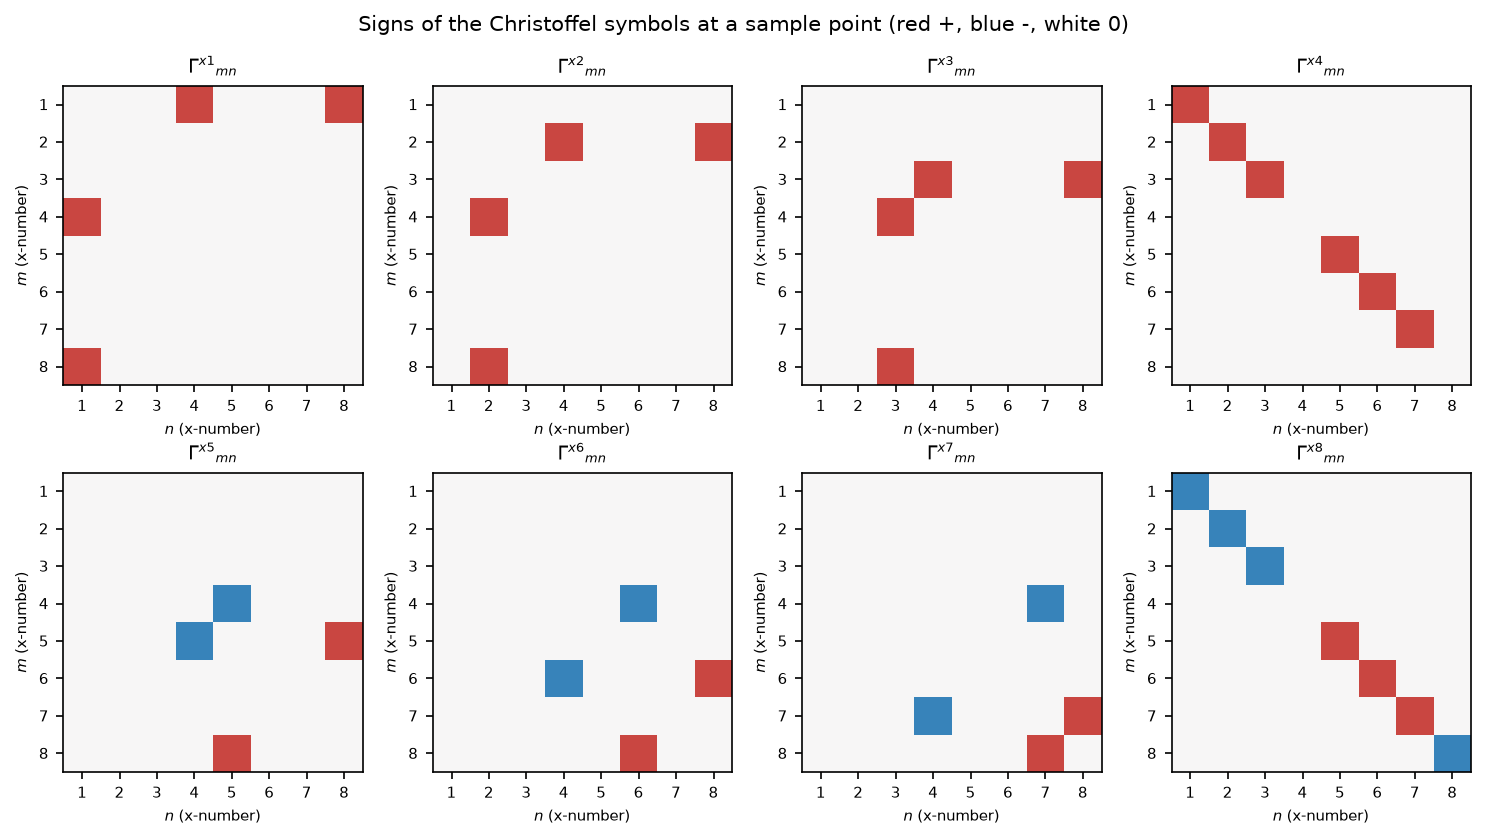

Figure 06a.3 saved as Revision/textbook/figures/06a_3_christoffel_pattern.png


In [10]:
SAMPLE = {H: 1, x8: sp.pi / 24}  # H = 1 and z = 6 H x8 = pi/4


def at_sample(expr):
    """The decimal value of expr at the sample point H = 1, z = pi/4, a4 = 1/2,
    a4' = 1/2, a4'' = 0 (derivatives are replaced first, then a4 itself)."""
    expr = sp.sympify(expr).subs(sp.Derivative(a4, (x4, 2)), 0)
    expr = expr.subs(sp.Derivative(a4, x4), sp.Rational(1, 2))
    expr = expr.subs(a4, sp.Rational(1, 2))
    return complex(sp.N(expr.subs(SAMPLE)))


fig, axes = plt.subplots(2, 4, figsize=(10.0, 5.6))
for l, ax in enumerate(axes.flat):
    signs = np.array([[np.sign(at_sample(Gam[l][m][n]).real) for n in range(8)]
                      for m in range(8)])
    ax.imshow(signs, cmap="RdBu_r", vmin=-1.5, vmax=1.5)
    ax.set_title(f"$\\Gamma^{{x{l + 1}}}{{}}_{{mn}}$", fontsize=9)
    ax.set_xticks(range(8), [f"{k + 1}" for k in range(8)], fontsize=7)
    ax.set_yticks(range(8), [f"{k + 1}" for k in range(8)], fontsize=7)
    ax.set_xlabel("$n$ (x-number)", fontsize=7)
    ax.set_ylabel("$m$ (x-number)", fontsize=7)
    ax.grid(False)
fig.suptitle("Signs of the Christoffel symbols at a sample point "
             "(red +, blue -, white 0)", fontsize=10)
fig.tight_layout()
save_figure(fig, "christoffel_pattern",
            "Where the Christoffel symbols $\\Gamma^l{}_{mn}$ of the author's metric "
            "are nonzero: one 8 x 8 grid per upper index $l = x1, \\dots, x8$, rows "
            "$m$ and columns $n$ numbered 1 to 8 for $x1$ to $x8$, each square "
            "coloured by the sign of the symbol at the sample point $H = 1$, $z = "
            "\\pi/4$, $a_4 = 1/2$, $a_4' = 1/2$ (red positive, blue negative, white "
            "zero). Every nonzero symbol has an index equal to 4 or 8: the metric "
            "depends only on the time $x_4$ and on the hidden coordinate $x_8$. The "
            "grids are symmetric because $\\Gamma^l{}_{mn} = \\Gamma^l{}_{nm}$.")

## 10. The canonical spin connection

The next cell computes $\omega_{\mu ab}$ with the general function and checks:

1. the vielbein postulate $\partial_\mu e^a{}_\nu - \sum_\lambda
   \Gamma^\lambda{}_{\mu\nu}e^a{}_\lambda + \sum_b \omega_\mu{}^a{}_b e^b{}_\nu = 0$
   in all $8 \cdot 8 \cdot 8 = 512$ components (here $\omega_\mu{}^a{}_b =
   \eta_{aa}\omega_{\mu ab}$, because $\eta_{aa}^2 = 1$);
2. the antisymmetry $\omega_{\mu ab} = -\omega_{\mu ba}$ (all 512 triples);
3. that exactly 12 components with $a < b$ are nonzero and equal the record's list
   `omega_nonzero` (entries $\{\mu, a, b, \text{value}\}$);
4. that every nonzero component is $a_4'$ or $H$ times a factor
   $\pm e^{\pm a_4}\sin^{1/6}z$ that never vanishes for $0 < z < \pi/2$: so the
   part of the spin connection made by the time dependence (3-space inflating,
   the extra times deflating) vanishes only if $a_4$ is constant, and the part
   made by the hidden direction never vanishes for $H > 0$.

In [11]:
omega = spin_connection(e, Gam, x, ETA)
postulate = [sp.diff(e[a, nu], x[mu])
             - sum(Gam[lam][mu][nu] * e[a, lam] for lam in range(8))
             + sum(ETA[a] * omega[mu][a][b] * e[b, nu] for b in range(8))
             for mu in range(8) for a in range(8) for nu in range(8)]
check(len(postulate) == 512 and all(is_zero(v) for v in postulate),
      "the vielbein postulate holds in all 512 components",
      record=f"{REPORT_PY}, check vielbein_postulate")
check(all(is_zero(omega[mu][a][b] + omega[mu][b][a])
          for mu in range(8) for a in range(8) for b in range(8)),
      "omega_mu ab = -omega_mu ba for all mu, a, b",
      record=f"{REPORT_PY}, check spin_connection_antisymmetric")
omega_nonzero = {(mu, a, b): omega[mu][a][b] for mu in range(8) for a in range(8)
                 for b in range(a + 1, 8) if omega[mu][a][b] != 0}
for (mu, a, b), value in omega_nonzero.items():
    say(f"omega_{NAMES[mu]},{NAMES[a]}{NAMES[b]} = {value}")
omega_record = {(int(m) - 1, int(a) - 1, int(b) - 1): v for m, a, b, v
                in record_formula("omega_nonzero", RECORD_NAMES)}
check(len(omega_nonzero) == 12 and set(omega_record) == set(omega_nonzero)
      and all(is_zero(omega_nonzero[k] - omega_record[k]) for k in omega_nonzero),
      "the 12 independent nonzero omega_mu ab equal the record",
      record=f"{THEORY_FILE}, formula omega_nonzero")
a4p = sp.Derivative(a4, x4)
factors = {sp.exp(a4) * s, -sp.exp(a4) * s, sp.exp(-a4) * s, -sp.exp(-a4) * s}
# value / (c * phys) must simplify to exactly 1 for one choice of c and phys.
shape_ok = all(any(sp.simplify(value / (c * phys)) == 1 for c in (a4p, H)
                   for phys in factors) for value in omega_nonzero.values())
check(shape_ok, "every nonzero omega is a4' or H times +-exp(+-a4) sin^(1/6) z",
      record=f"{REPORT_WL}, check Omega_vanishes_iff_a4prime_and_H_vanish")

PASS the vielbein postulate holds in all 512 components
     reproduces Revision/theory/reports/python-field-theory.json, check
    vielbein_postulate
PASS omega_mu ab = -omega_mu ba for all mu, a, b
     reproduces Revision/theory/reports/python-field-theory.json, check
    spin_connection_antisymmetric
omega_x1,x1x4 = exp(a4(x4))*sin(6*H*x8)**(1/6)*Derivative(a4(x4), x4)
omega_x1,x1x8 = H*exp(a4(x4))*sin(6*H*x8)**(1/6)
omega_x2,x2x4 = exp(a4(x4))*sin(6*H*x8)**(1/6)*Derivative(a4(x4), x4)
omega_x2,x2x8 = H*exp(a4(x4))*sin(6*H*x8)**(1/6)
omega_x3,x3x4 = exp(a4(x4))*sin(6*H*x8)**(1/6)*Derivative(a4(x4), x4)
omega_x3,x3x8 = H*exp(a4(x4))*sin(6*H*x8)**(1/6)
omega_x5,x4x5 = -exp(-a4(x4))*sin(6*H*x8)**(1/6)*Derivative(a4(x4), x4)
omega_x5,x5x8 = -H*exp(-a4(x4))*sin(6*H*x8)**(1/6)
omega_x6,x4x6 = -exp(-a4(x4))*sin(6*H*x8)**(1/6)*Derivative(a4(x4), x4)
omega_x6,x6x8 = -H*exp(-a4(x4))*sin(6*H*x8)**(1/6)
omega_x7,x4x7 = -exp(-a4(x4))*sin(6*H*x8)**(1/6)*Derivative(a4(x4), x4)
omega_x7,x7x8 = -H*

The next cell draws two of the eight 8 x 8 arrays $\omega_{\mu ab}$ at the sample
point: for $\mu = x1$ (an inflating 3-space direction) and for $\mu = x5$ (a
deflating extra time). Each array is antisymmetric: the square $(a, b)$ has the
opposite colour of the square $(b, a)$, and the diagonal is white. For $\mu = x1$
the frame direction $x1$ turns towards the time $x4$ (rate $a_4' e^{a_4}s$) and
towards the hidden direction $x8$ (rate $H e^{a_4}s$); for $\mu = x5$ the signs are
reversed, because the extra times shrink while 3-space grows.

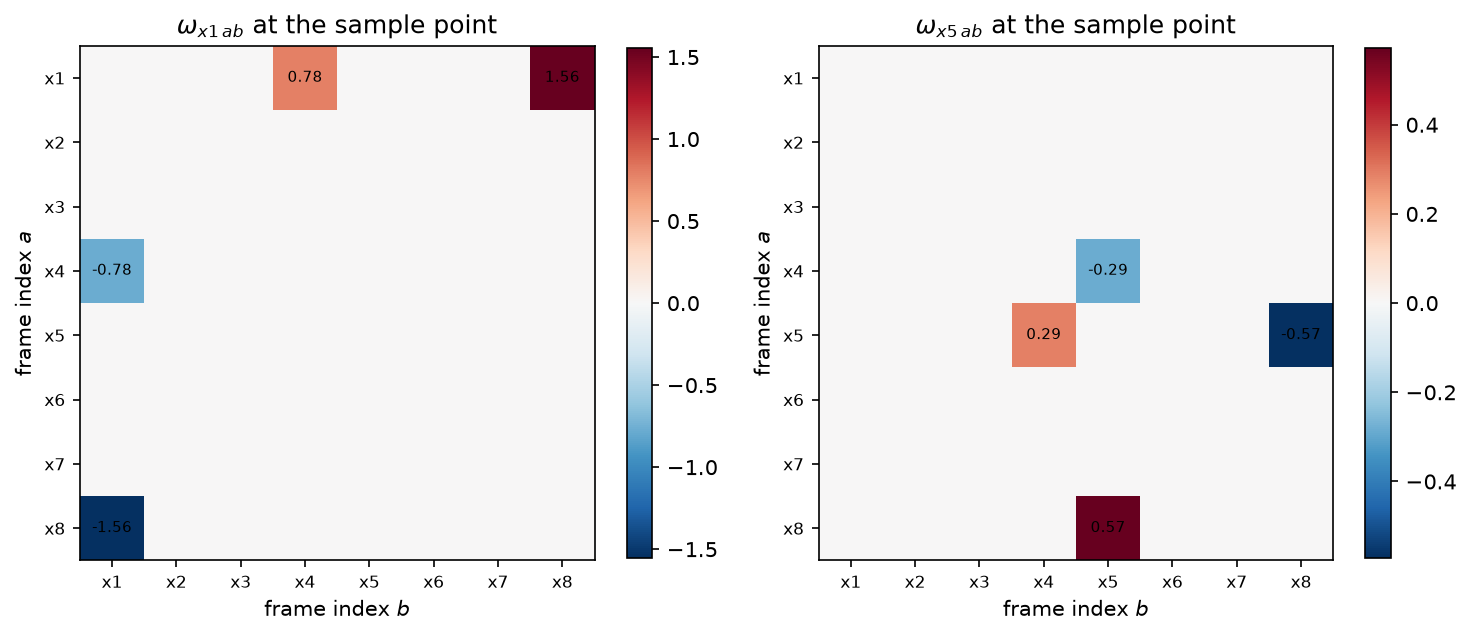

Figure 06a.4 saved as Revision/textbook/figures/06a_4_omega_heat_maps.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.6))
for ax, mu in zip(axes, (0, 4)):
    table = np.array([[at_sample(omega[mu][a][b]).real for b in range(8)]
                      for a in range(8)])
    limit = np.abs(table).max()
    image = ax.imshow(table, cmap="RdBu_r", vmin=-limit, vmax=limit)
    for a in range(8):
        for b in range(8):
            if table[a, b] != 0:
                ax.text(b, a, f"{table[a, b]:.2f}", ha="center", va="center",
                        fontsize=7)
    ax.set_xticks(range(8), NAMES, fontsize=8)
    ax.set_yticks(range(8), NAMES, fontsize=8)
    ax.set_xlabel("frame index $b$")
    ax.set_ylabel("frame index $a$")
    ax.set_title(f"$\\omega_{{x{mu + 1}\\,ab}}$ at the sample point")
    ax.grid(False)
    fig.colorbar(image, ax=ax, shrink=0.8)
fig.tight_layout()
save_figure(fig, "omega_heat_maps",
            "The canonical spin connection $\\omega_{\\mu ab}$ of the diagonal "
            "vielbein as two heat maps, for $\\mu = x1$ (left, an inflating 3-space "
            "direction) and $\\mu = x5$ (right, a deflating extra time), at the "
            "sample point $H = 1$, $z = \\pi/4$, $a_4 = 1/2$, $a_4' = 1/2$; rows $a$ "
            "and columns $b$ are the frame directions $x1$ to $x8$, the colour and "
            "the printed number give the value (red positive, blue negative, white "
            "zero). Each array is antisymmetric, and only the pairs with $x4$ or "
            "$x8$ are nonzero; the extra time $x5$ has the opposite signs of the "
            "3-space direction $x1$.")

## 11. The spinor connection $\Omega_\mu$ and the covariant constancy of the gammas

The next cell builds the eight 16 x 16 matrices $\Omega_\mu$ and the curved gammas
$\gamma^\mu = \gamma^a/f_a$ (no sum) and checks:

1. $\Omega_{x4} = \Omega_{x8} = 0$: no frame direction turns when one moves along
   the time or along the hidden direction;
2. the defining property of the spinor connection, $[\Omega_\mu, \gamma^a] =
   -\sum_b \omega_\mu{}^a{}_b \gamma^b$ for all 64 pairs $(\mu, a)$: commuting
   with $\Omega_\mu$ turns the gammas exactly as $\omega_\mu$ turns the frame;
3. the covariant constancy of the curved gammas, $D_\mu\gamma^\nu = \partial_\mu
   \gamma^\nu + \sum_\lambda\Gamma^\nu{}_{\mu\lambda}\gamma^\lambda + [\Omega_\mu,
   \gamma^\nu] = 0$ for all 64 pairs $(\mu, \nu)$, which is the vielbein postulate
   written with gammas.

In [13]:
Omega = spinor_connection(omega, S)  # eight 16 x 16 matrices
gup = curved_gammas(e, gamma)  # gamma^mu = gamma^a / f_a for mu = a
check(Omega[3] == Z16 and Omega[7] == Z16, "Omega_x4 = Omega_x8 = 0",
      record=f"{REPORT_PY}, check Omega_x4_and_Omega_x8_vanish")
rotation_ok = all(matrix_is_zero(
    Omega[mu] * gamma[a] - gamma[a] * Omega[mu]
    + sum((ETA[a] * omega[mu][a][b] * gamma[b] for b in range(8)), Z16))
    for mu in range(8) for a in range(8))
check(rotation_ok, "[Omega_mu, gamma^a] = -omega_mu^a_b gamma^b for all 64 pairs",
      record=f"{REPORT_WL}, check S_rotates_gamma_with_omega")
constancy_ok = all(matrix_is_zero(
    gup[nu].diff(x[mu]) + sum((Gam[nu][mu][lam] * gup[lam] for lam in range(8)), Z16)
    + Omega[mu] * gup[nu] - gup[nu] * Omega[mu])
    for mu in range(8) for nu in range(8))
check(constancy_ok, "D_mu gamma^nu = 0 for all 64 pairs (mu, nu)",
      record=f"{REPORT_PY}, check covariant_constancy_D_mu_gamma_nu")
say(f"Omega_x1 has {sum(1 for v in Omega[0] if v != 0)} nonzero entries of 256")

PASS Omega_x4 = Omega_x8 = 0
     reproduces Revision/theory/reports/python-field-theory.json, check
    Omega_x4_and_Omega_x8_vanish
PASS [Omega_mu, gamma^a] = -omega_mu^a_b gamma^b for all 64 pairs
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    S_rotates_gamma_with_omega
PASS D_mu gamma^nu = 0 for all 64 pairs (mu, nu)
     reproduces Revision/theory/reports/python-field-theory.json, check
    covariant_constancy_D_mu_gamma_nu
Omega_x1 has 32 nonzero entries of 256


Each $\Omega_\mu$ is a combination of two of the matrices $S^{ab}$:
$\Omega_{x1} = e^{a_4}s\,(a_4' S^{x1\,x4} + H S^{x1\,x8})$ and $\Omega_{x5} =
-e^{-a_4}s\,(a_4' S^{x4\,x5} + H S^{x5\,x8})$. The author's gammas are real, the
four space-like ones are symmetric matrices and the four time-like ones are
antisymmetric. Because of this, $S^{ab} = \frac12\gamma^a\gamma^b$ ($a \ne b$)
is a SYMMETRIC matrix when one of $a, b$ is space-like and the other time-like
(a **boost**, 16 pairs), and an ANTISYMMETRIC matrix when both are of the same
kind (a **rotation**, 12 pairs). The next cell checks this for all 28 pairs and
then draws $\Omega_{x1}$ and $\Omega_{x5}$ as 16 x 16 heat maps at the sample
point. In $\Omega_{x1}$ the $a_4'$ part is a boost ($x1$ with the time $x4$,
symmetric) and the $H$ part a rotation ($x1$ with $x8$, antisymmetric); in
$\Omega_{x5}$ it is the other way round ($x4$ with $x5$ is a rotation of two
time-like directions, $x5$ with $x8$ a boost).

PASS S^ab is symmetric for the 16 boosts, antisymmetric for the 12 rotations


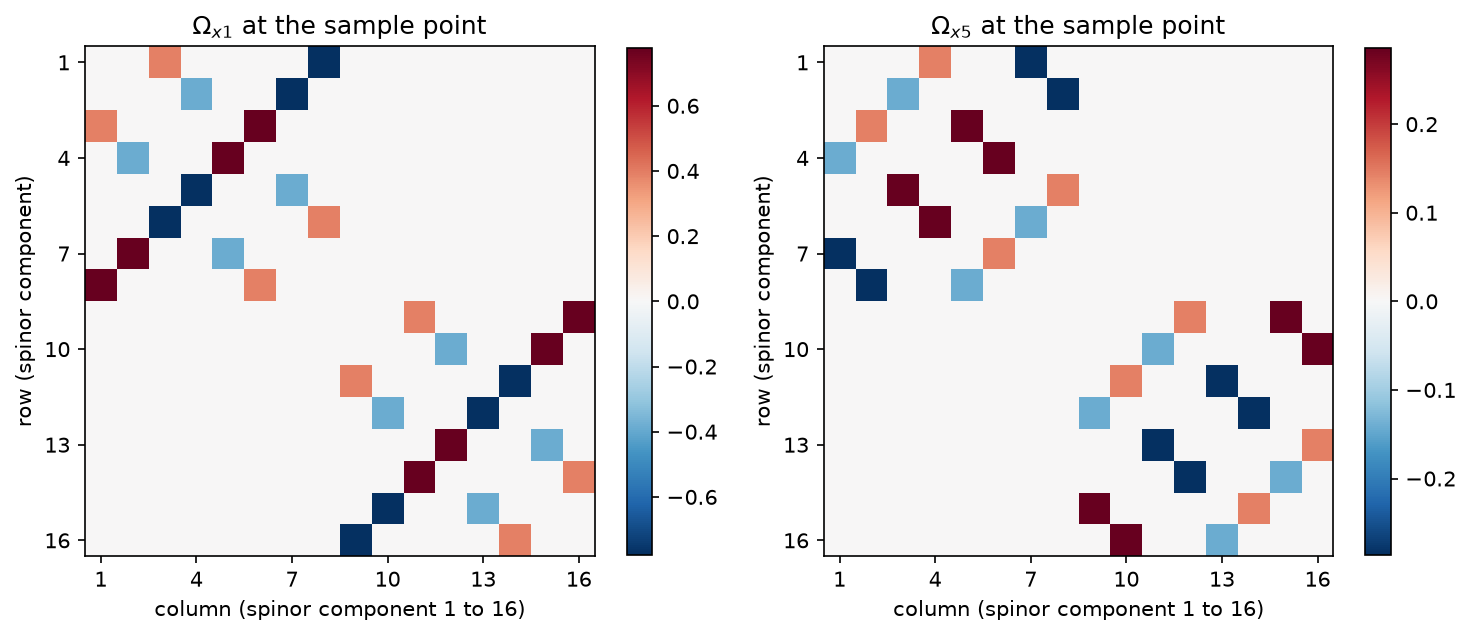

Figure 06a.5 saved as Revision/textbook/figures/06a_5_spinor_connection_heat_maps.png


In [14]:
pattern_ok = True
for a in range(8):
    for b in range(a + 1, 8):
        boost = ETA[a] * ETA[b] == -1  # one space-like, one time-like direction
        want = S[a][b] if boost else -S[a][b]  # S^T = S (boost) or -S (rotation)
        pattern_ok = pattern_ok and S[a][b].T == want
check(pattern_ok, "S^ab is symmetric for the 16 boosts, antisymmetric for the 12 "
      "rotations")
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.6))
for ax, mu in zip(axes, (0, 4)):
    table = np.array([[at_sample(v).real for v in row] for row in Omega[mu].tolist()])
    limit = np.abs(table).max()
    image = ax.imshow(table, cmap="RdBu_r", vmin=-limit, vmax=limit)
    ax.set_xticks(range(0, 16, 3), [str(k + 1) for k in range(0, 16, 3)])
    ax.set_yticks(range(0, 16, 3), [str(k + 1) for k in range(0, 16, 3)])
    ax.set_xlabel("column (spinor component 1 to 16)")
    ax.set_ylabel("row (spinor component)")
    ax.set_title(f"$\\Omega_{{x{mu + 1}}}$ at the sample point")
    ax.grid(False)
    fig.colorbar(image, ax=ax, shrink=0.8)
fig.tight_layout()
save_figure(fig, "spinor_connection_heat_maps",
            "The spinor connection $\\Omega_{x1}$ (left) and $\\Omega_{x5}$ (right) as "
            "16 x 16 heat maps at the sample point $H = 1$, $z = \\pi/4$, $a_4 = 1/2$, "
            "$a_4' = 1/2$; rows and columns are the 16 spinor components, red is "
            "positive, blue negative, white zero. Each matrix is a sum of two of the "
            "generators $S^{ab}$: a boost, which is a symmetric matrix (entries "
            "$(i, j)$ and $(j, i)$ of the same colour), and a rotation, which is "
            "antisymmetric (opposite colours). Both matrices map the first eight "
            "components to the first eight and the last eight to the last eight.")

## 12. The contraction $\gamma^\mu\Omega_\mu = 3H\gamma^{(x8)}$

The field equation contains $\gamma^\mu D_\mu\Psi = \gamma^\mu\partial_\mu\Psi +
\gamma^\mu\Omega_\mu\Psi$, so the spin connection enters it only through the
16 x 16 matrix $\gamma^\mu\Omega_\mu$ (summed over $\mu$). The next cell computes
each term $\gamma^\mu\Omega_\mu$ (no sum) separately and writes it as
$\alpha_\mu\gamma^{(x4)} + \beta_\mu\gamma^{(x8)}$. The numbers $\alpha_\mu$ and
$\beta_\mu$ are found with traces: for two different gammas
$\mathrm{tr}(\gamma^a\gamma^b) = 0$, while $\mathrm{tr}(\gamma^{(x4)}
\gamma^{(x4)}) = -16$ and $\mathrm{tr}(\gamma^{(x8)}\gamma^{(x8)}) = +16$, so
$\alpha_\mu = -\mathrm{tr}(M\gamma^{(x4)})/16$ and $\beta_\mu =
\mathrm{tr}(M\gamma^{(x8)})/16$ for $M = \gamma^\mu\Omega_\mu$; the cell then
checks that $M - \alpha_\mu\gamma^{(x4)} - \beta_\mu\gamma^{(x8)}$ is the zero
matrix. It compares the table with the record (`gammaOmega_per_direction`) and the
sum with $3H\gamma^{(x8)}$.

In [15]:
per_direction = []  # (alpha_mu, beta_mu) for mu = x1 ... x8
decomposed = True
for mu in range(8):
    M = (gup[mu] * Omega[mu]).applyfunc(sp.simplify)
    alpha = sp.simplify(-(M * gamma[3]).trace() / 16)  # coefficient of gamma^(x4)
    beta = sp.simplify((M * gamma[7]).trace() / 16)  # coefficient of gamma^(x8)
    decomposed = decomposed and matrix_is_zero(M - alpha * gamma[3] - beta * gamma[7])
    per_direction.append((alpha, beta))
    say(f"gamma^{NAMES[mu]} Omega_{NAMES[mu]} = ({alpha}) gamma^(x4) "
        f"+ ({beta}) gamma^(x8)")
table_record = record_formula("gammaOmega_per_direction", RECORD_NAMES)
check(decomposed and all(is_zero(per_direction[k][0] - table_record[k][1])
                         and is_zero(per_direction[k][1] - table_record[k][2])
                         for k in range(8)),
      "the eight terms gamma^mu Omega_mu (no sum) equal the record",
      record=f"{THEORY_FILE}, formula gammaOmega_per_direction")
inflating = sp.simplify(sum(per_direction[k][0] for k in (0, 1, 2)))
deflating = sp.simplify(sum(per_direction[k][0] for k in (4, 5, 6)))
hidden = sp.simplify(sum(beta for _, beta in per_direction))
report("x4 part from the inflating x1, x2, x3", inflating)
report("x4 part from the deflating x5, x6, x7", deflating)
report("x8 part from all directions", hidden)
check(is_zero(inflating + deflating) and is_zero(hidden - 3 * H),
      "the x4 terms cancel (3a4'/2 - 3a4'/2 = 0); the x8 terms add to 3H",
      record=f"{REPORT_WL}, check gammaOmega_x4_terms_cancel")
slash = sum((gup[mu] * Omega[mu] for mu in range(8)), Z16)
check(matrix_is_zero(slash - 3 * H * gamma[7])
      and record_passed(REPORT_LEAD, "gamma_Omega_equals_3H_gamma8"),
      "gamma^mu Omega_mu = 3 H gamma^(x8) exactly, for every a4 and H",
      record=f"{REPORT_LEAD}, check gamma_Omega_equals_3H_gamma8")

gamma^x1 Omega_x1 = (Derivative(a4(x4), x4)/2) gamma^(x4) + (H/2) gamma^(x8)
gamma^x2 Omega_x2 = (Derivative(a4(x4), x4)/2) gamma^(x4) + (H/2) gamma^(x8)
gamma^x3 Omega_x3 = (Derivative(a4(x4), x4)/2) gamma^(x4) + (H/2) gamma^(x8)
gamma^x4 Omega_x4 = (0) gamma^(x4) + (0) gamma^(x8)
gamma^x5 Omega_x5 = (-Derivative(a4(x4), x4)/2) gamma^(x4) + (H/2) gamma^(x8)
gamma^x6 Omega_x6 = (-Derivative(a4(x4), x4)/2) gamma^(x4) + (H/2) gamma^(x8)
gamma^x7 Omega_x7 = (-Derivative(a4(x4), x4)/2) gamma^(x4) + (H/2) gamma^(x8)
gamma^x8 Omega_x8 = (0) gamma^(x4) + (0) gamma^(x8)
PASS the eight terms gamma^mu Omega_mu (no sum) equal the record
     reproduces Revision/theory/field-theory.json, formula gammaOmega_per_direction
RESULT x4 part from the inflating x1, x2, x3 = 3*Derivative(a4(x4), x4)/2
RESULT x4 part from the deflating x5, x6, x7 = -3*Derivative(a4(x4), x4)/2
RESULT x8 part from all directions = 3*H
PASS the x4 terms cancel (3a4'/2 - 3a4'/2 = 0); the x8 terms add to 3H
     reproduces Revis

The next cell draws the table of the previous cell as two bar charts: on the left
the coefficient $\alpha_\mu$ of $\gamma^{(x4)}$ in units of $a_4'$, on the right the
coefficient $\beta_\mu$ of $\gamma^{(x8)}$ in units of $H$, for each direction
$\mu$. The left bars cancel in pairs (three up, three down: total $0$); the right
bars all point the same way (six times $\frac12$: total $3$).

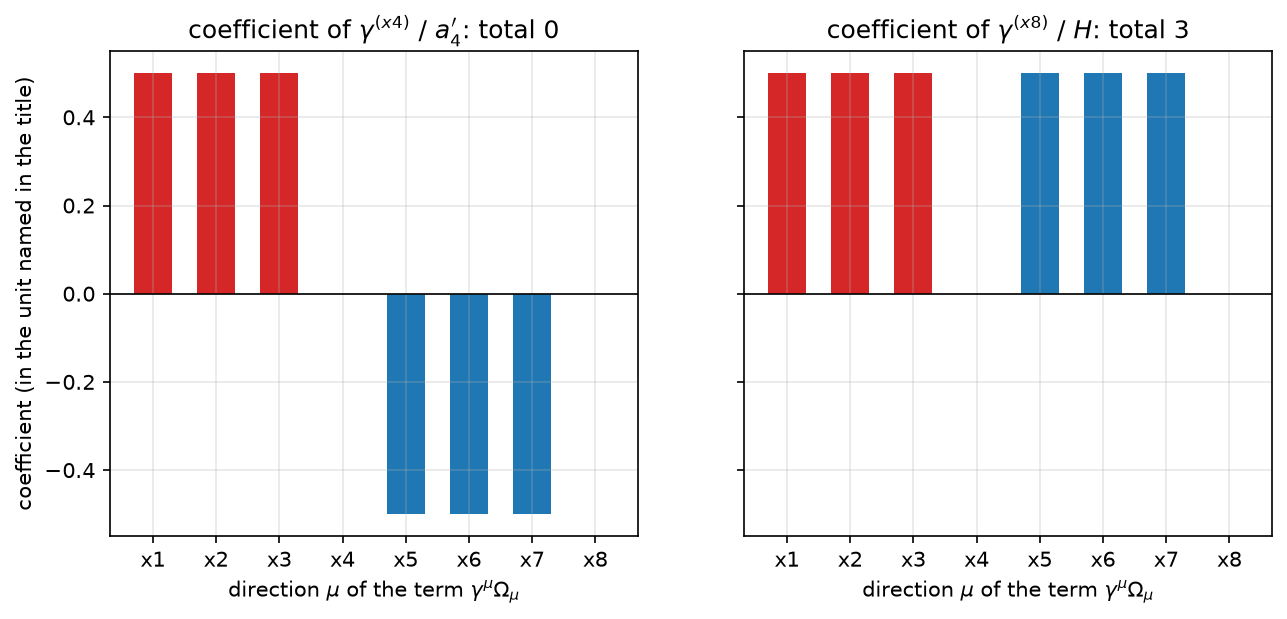

Figure 06a.6 saved as Revision/textbook/figures/06a_6_gamma_omega_per_direction.png


In [16]:
alpha_units = [float(sp.simplify(alpha / sp.Derivative(a4, x4))) for alpha, _
               in per_direction]  # alpha_mu / a4'
beta_units = [float(sp.simplify(beta / H)) for _, beta in per_direction]  # beta / H
positions = np.arange(8)
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(10.0, 4.2), sharey=True)
colors = ["tab:red"] * 3 + ["gray"] + ["tab:blue"] * 3 + ["gray"]
ax_left.bar(positions, alpha_units, color=colors, width=0.6)
ax_left.set_title(f"coefficient of $\\gamma^{{(x4)}}$ / $a_4'$: total "
                  f"{sum(alpha_units):g}")
ax_right.bar(positions, beta_units, color=colors, width=0.6)
ax_right.set_title(f"coefficient of $\\gamma^{{(x8)}}$ / $H$: total "
                   f"{sum(beta_units):g}")
for ax in (ax_left, ax_right):
    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.set_xticks(positions, NAMES)
    ax.set_xlabel("direction $\\mu$ of the term $\\gamma^\\mu\\Omega_\\mu$")
ax_left.set_ylabel("coefficient (in the unit named in the title)")
save_figure(fig, "gamma_omega_per_direction",
            "The eight terms $\\gamma^\\mu\\Omega_\\mu$ (no sum) of the diagonal "
            "vielbein, each equal to $\\alpha_\\mu\\gamma^{(x4)} + "
            "\\beta_\\mu\\gamma^{(x8)}$. Left: $\\alpha_\\mu$ in units of $a_4'$; "
            "right: $\\beta_\\mu$ in units of $H$; horizontal axis the direction "
            "$\\mu$ (red: inflating 3-space, blue: deflating extra times, gray: time "
            "and hidden direction). The time-direction coefficients $+1/2$ of "
            "$x1, x2, x3$ and $-1/2$ of $x5, x6, x7$ cancel, while the six "
            "hidden-direction coefficients $1/2$ add to $3$: $\\gamma^\\mu\\Omega_\\mu "
            "= 3H\\gamma^{(x8)}$.")

The next cell shows the same cancellation as pictures of the 16 x 16 matrices at
the sample point ($H = 1$, $a_4' = 1/2$): the sum of the three inflating terms, the
sum of the three deflating terms, the total $\gamma^\mu\Omega_\mu$, and
$3H\gamma^{(x8)}$. The first two pictures contain the same $\gamma^{(x4)}$ pattern
with opposite colours (the entries of size $\frac32 a_4' = 0.75$), on top of the
same $\gamma^{(x8)}$ pattern (entries $\frac32 H = 1.5$); in the total the
$\gamma^{(x4)}$ pattern is gone, and the total is the picture of $3H\gamma^{(x8)}$.
The author's $\gamma^{(x8)}$ has the 8 x 8 identity matrix in its upper-right and
lower-left blocks and zeros elsewhere: it maps the first eight spinor components
onto the last eight and back, so $3H\gamma^{(x8)}$ shows the value 3 on two
diagonal lines. The cell first checks the block form of all eight gammas against
the record's list `field_equation_blocks`: each entry $\{xa, \bar t, t\}$ says that
$\gamma^{(xa)}$ has the 8 x 8 block $\bar t$ in its upper-right corner, the block
$t$ in its lower-left corner and zeros in the two diagonal blocks. The record is
written with curly brackets; replacing them by square brackets turns each entry
into JSON, which `json.loads` reads.

PASS the eight gammas have the block form of the record
     reproduces Revision/theory/field-theory.json, formula field_equation_blocks
PASS gamma^(x8) has the 8 x 8 identity in its two off-diagonal blocks


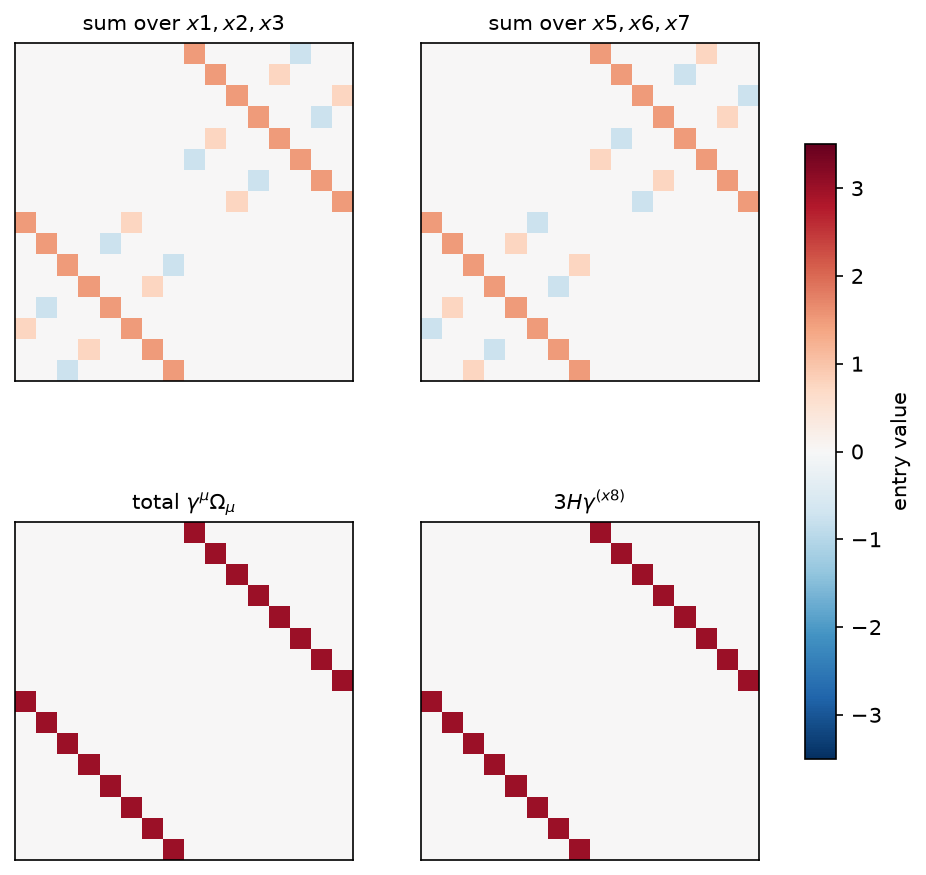

Figure 06a.7 saved as Revision/textbook/figures/06a_7_gamma_omega_cancellation.png


In [17]:
I8, Z8 = sp.eye(8), sp.zeros(8, 8)  # 8 x 8 identity and zero matrices
blocks_ok = True
for entry in FORMULAS["field_equation_blocks"]:  # eight texts {"xa", tb, t}
    name, tb, t = json.loads(entry.replace("{", "[").replace("}", "]"))
    a = NAMES.index(name)  # the position of the direction xa (0 ... 7)
    # gamma^(xa) must be the block matrix with the zero blocks on the diagonal
    blocks_ok = blocks_ok and gamma[a] == sp.BlockMatrix(
        [[Z8, sp.Matrix(tb)], [sp.Matrix(t), Z8]]).as_explicit()
check(blocks_ok and len(FORMULAS["field_equation_blocks"]) == 8,
      "the eight gammas have the block form of the record",
      record=f"{THEORY_FILE}, formula field_equation_blocks")
check(gamma[7] == sp.BlockMatrix([[Z8, I8], [I8, Z8]]).as_explicit(),
      "gamma^(x8) has the 8 x 8 identity in its two off-diagonal blocks")
panels = [
    ("sum over $x1, x2, x3$", sum((gup[k] * Omega[k] for k in (0, 1, 2)), Z16)),
    ("sum over $x5, x6, x7$", sum((gup[k] * Omega[k] for k in (4, 5, 6)), Z16)),
    ("total $\\gamma^\\mu\\Omega_\\mu$", slash),
    ("$3H\\gamma^{(x8)}$", 3 * H * gamma[7]),
]
fig, axes = plt.subplots(2, 2, figsize=(8.0, 7.6))
for ax, (title, matrix) in zip(axes.flat, panels):
    table = np.array([[at_sample(v).real for v in row] for row in matrix.tolist()])
    image = ax.imshow(table, cmap="RdBu_r", vmin=-3.5, vmax=3.5)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
fig.colorbar(image, ax=axes, shrink=0.7, label="entry value")
save_figure(fig, "gamma_omega_cancellation",
            "The cancellation as pictures of 16 x 16 matrices at the sample point "
            "$H = 1$, $z = \\pi/4$, $a_4 = 1/2$, $a_4' = 1/2$ (red positive, blue "
            "negative, white zero; colour scale from $-3.5$ to $3.5$). Top left: the "
            "sum of the three inflating terms $\\gamma^\\mu\\Omega_\\mu$, $\\mu = x1, "
            "x2, x3$; top right: the sum of the three deflating terms, $\\mu = x5, x6, "
            "x7$; their $\\gamma^{(x4)}$ parts have opposite signs. Bottom left: the "
            "total over all eight directions; bottom right: $3H\\gamma^{(x8)}$. The "
            "two bottom pictures are identical.")

## 13. Why the function $a_4$ drops out: the divergence form

Two facts explain the result without computing all of $\Omega_\mu$.

**Fact 1.** For each $\mu$ separately, $\gamma^\mu\Omega_\mu + \Omega_\mu\gamma^\mu
= 0$ (no sum). Now sum the covariant constancy $D_\mu\gamma^\nu = 0$ over
$\mu = \nu$: $\sum_\mu\partial_\mu\gamma^\mu + \sum_{\mu,\lambda}
\Gamma^\mu{}_{\mu\lambda}\gamma^\lambda + \sum_\mu(\Omega_\mu\gamma^\mu -
\gamma^\mu\Omega_\mu) = 0$. The standard contraction $\sum_\mu
\Gamma^\mu{}_{\mu\lambda} = \partial_\lambda \ln\sqrt{|g|}$ turns the first two sums
into $\frac{1}{\sqrt{|g|}}\sum_\mu\partial_\mu(\sqrt{|g|}\,\gamma^\mu)$ (product
rule), and Fact 1 turns the last sum into $-2\sum_\mu\gamma^\mu\Omega_\mu$. Solving
for the contraction gives

$$\gamma^\mu\Omega_\mu = \frac{1}{2\sqrt{|g|}}\sum_\mu \partial_\mu\big(\sqrt{|g|}\,
\gamma^\mu\big) .$$

**Fact 2.** For the diagonal vielbein, $\sqrt{|g|}\gamma^\mu = \big(\prod_{c \ne
\mu} f_c\big)\gamma^{(\mu)}$, because $\sqrt{|g|} = \prod_c f_c$ and $\gamma^\mu =
\gamma^{(\mu)}/f_\mu$. Now $\prod_{c \ne x4} f_c = \cos z$ does not depend on $x_4$
(the factors $e^{3a_4}$ and $e^{-3a_4}$ cancel), so the time direction contributes
nothing, and $\prod_{c \ne x8} f_c = \sin z$ gives $\frac{1}{2\cos z}\,\partial_{x8}
\sin z = \frac{6H\cos z}{2\cos z} = 3H$. The other six products do not depend on
their own coordinate.

The next cell checks Fact 1 for every $\mu$, the divergence form, and the eight
products of Fact 2.

In [18]:
anticommutes = all(matrix_is_zero(gup[mu] * Omega[mu] + Omega[mu] * gup[mu])
                   for mu in range(8))
check(anticommutes, "{gamma^mu, Omega_mu} = 0 for each mu separately",
      record=f"{REPORT_PY}, check anticommutator_gamma_Omega_vanishes")
sqrt_g = sp.cos(z)
divergence = sum(((sqrt_g * gup[mu]).diff(x[mu]) for mu in range(8)), Z16) / (2 * sqrt_g)
check(matrix_is_zero(divergence - 3 * H * gamma[7])
      and record_passed(REPORT_LEAD, "gamma_Omega_divergence_formula"),
      "(1/(2 sqrt|g|)) d_mu (sqrt|g| gamma^mu) = 3 H gamma^(x8)",
      record=f"{REPORT_LEAD}, check gamma_Omega_divergence_formula")
products = [sp.simplify(sp.prod([f[c] for c in range(8) if c != b])) for b in range(8)]
for b in (3, 7):
    say(f"product of the f_c with c != {NAMES[b]}: {products[b]}")
own_coordinate = [sp.simplify(sp.diff(products[b], x[b]) / (2 * sqrt_g))
                  for b in range(8)]
say(f"(1/(2 cos z)) d_b (product without b), b = x1 ... x8: {own_coordinate}")
check(own_coordinate == [0] * 7 + [3 * H],
      "only the hidden direction contributes, with 3 H")

PASS {gamma^mu, Omega_mu} = 0 for each mu separately
     reproduces Revision/theory/reports/python-field-theory.json, check
    anticommutator_gamma_Omega_vanishes
PASS (1/(2 sqrt|g|)) d_mu (sqrt|g| gamma^mu) = 3 H gamma^(x8)
     reproduces Revision/lead_checks/reports/emt-divergence-and-spin-connection.json,
    check gamma_Omega_divergence_formula
product of the f_c with c != x4: cos(6*H*x8)
product of the f_c with c != x8: sin(6*H*x8)
(1/(2 cos z)) d_b (product without b), b = x1 ... x8: [0, 0, 0, 0, 0, 0, 0, 3*H]
PASS only the hidden direction contributes, with 3 H


The next cell checks Fact 2 with numbers instead of symbols, as a student would with
a calculator: it computes the derivative of $\sin z$ with respect to $x_8$ by a
**central difference**, $\big(F(x_8 + h) - F(x_8 - h)\big)/(2h)$ with the small
step $h = 10^{-5}$, divides by $2\cos z$, and plots the result over the whole
range of $z$ (with $H = 1$). It also does the same for the time direction, where
the product $\cos z$ does not depend on $x_4$ at all. The difference from the exact
value 3 is of the size $18h^2 \approx 2 \cdot 10^{-9}$ (the error of a central
difference is $h^2/6$ times the third derivative), far below the check limit
$10^{-6}$.

RESULT largest |central difference - 3 H| over the grid = 1.9e-09
PASS the numerical derivative gives 3 H


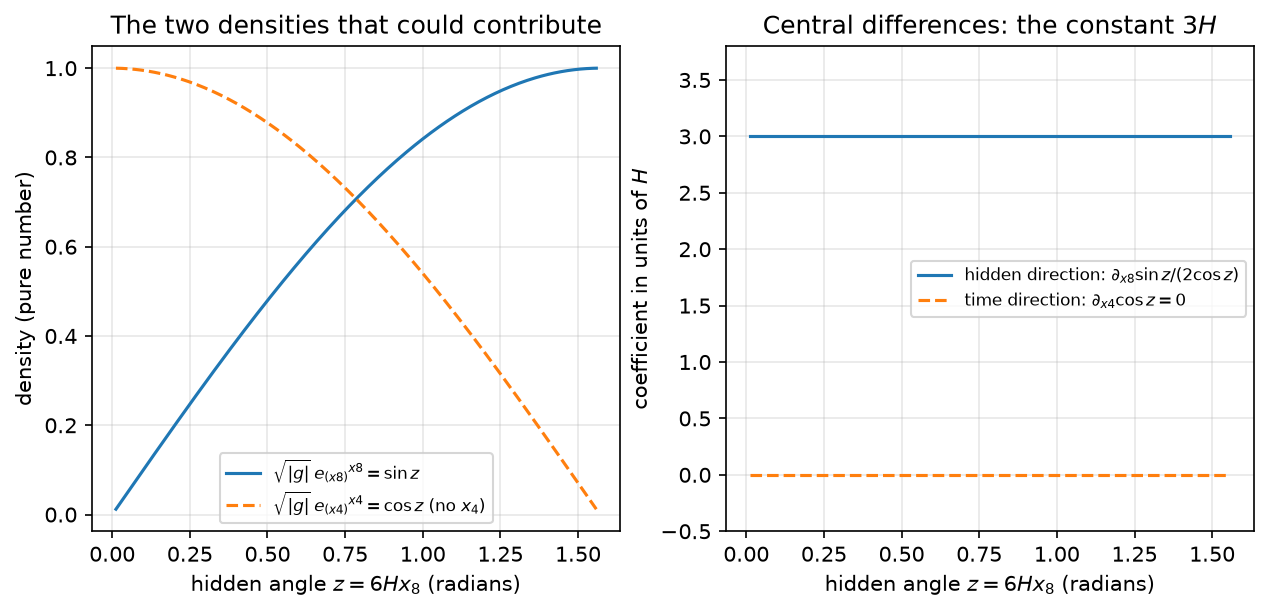

Figure 06a.8 saved as Revision/textbook/figures/06a_8_divergence_form.png


In [19]:
H_value = 1.0
x8_values = np.linspace(0.002, np.pi / 12 - 0.002, 300)  # z = 6 x8 inside (0, pi/2)
step = 1e-5  # the step h of the central difference


def hidden_product(x8_value):
    return np.sin(6 * H_value * x8_value)  # sqrt|g| e_(x8)^x8 = sin z


derivative = (hidden_product(x8_values + step)
              - hidden_product(x8_values - step)) / (2 * step)
ratio = derivative / (2 * np.cos(6 * H_value * x8_values))  # should be 3 H = 3
time_term = np.zeros_like(x8_values)  # d/dx4 cos z = 0: the time contributes 0
report("largest |central difference - 3 H| over the grid",
       f"{np.max(np.abs(ratio - 3.0)):.1e}")
check(np.max(np.abs(ratio - 3.0)) < 1e-6, "the numerical derivative gives 3 H")
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(10.0, 4.2))
zz = 6 * H_value * x8_values
ax_left.plot(zz, np.sin(zz), label="$\\sqrt{|g|}\\,e_{(x8)}{}^{x8} = \\sin z$")
ax_left.plot(zz, np.cos(zz), "--",
             label="$\\sqrt{|g|}\\,e_{(x4)}{}^{x4} = \\cos z$ (no $x_4$)")
ax_left.set_xlabel("hidden angle $z = 6Hx_8$ (radians)")
ax_left.set_ylabel("density (pure number)")
ax_left.set_title("The two densities that could contribute")
ax_left.legend(fontsize=8)
ax_right.plot(zz, ratio, label="hidden direction: $\\partial_{x8}\\sin z/(2\\cos z)$")
ax_right.plot(zz, time_term, "--", label="time direction: $\\partial_{x4}\\cos z = 0$")
ax_right.set_ylim(-0.5, 3.8)
ax_right.set_xlabel("hidden angle $z = 6Hx_8$ (radians)")
ax_right.set_ylabel("coefficient in units of $H$")
ax_right.set_title("Central differences: the constant $3H$")
ax_right.legend(fontsize=8, loc="center right")
save_figure(fig, "divergence_form",
            "The divergence form of $\\gamma^\\mu\\Omega_\\mu$ with $H = 1$. Left: the "
            "densities $\\sqrt{|g|}\\,e_{(x8)}{}^{x8} = \\sin z$ and "
            "$\\sqrt{|g|}\\,e_{(x4)}{}^{x4} = \\cos z$ versus the hidden angle $z$ in "
            "radians; the second does not depend on the time $x_4$, so the time "
            "direction contributes nothing. Right: the coefficient of "
            "$\\gamma^{(x8)}$, $\\partial_{x8}\\sin z/(2\\cos z)$, computed by central "
            "differences with step $10^{-5}$ (solid), is the constant $3$ for every "
            "$z$, and the time-direction coefficient is $0$ (dashed).")

## 14. The covariant derivative of a spinor and the Dirac operator written out

The next cell takes a completely general spinor field: 16 unknown functions
$\psi_1, \dots, \psi_{16}$ of all eight coordinates. It computes the covariant
derivatives $D_\mu\Psi = \partial_\mu\Psi + \Omega_\mu\Psi$ and the Dirac operator
$\gamma^\mu D_\mu\Psi$, and checks that

$$\gamma^\mu D_\mu\Psi = \sum_a \frac{1}{f_a}\gamma^{(a)}\partial_a\Psi +
3H\gamma^{(x8)}\Psi ,$$

that is, with the factors written out,
$e^{-a_4}s^{-1}(\gamma^{(x1)}\partial_1 + \gamma^{(x2)}\partial_2 +
\gamma^{(x3)}\partial_3)\Psi + \gamma^{(x4)}\partial_4\Psi +
e^{a_4}s^{-1}(\gamma^{(x5)}\partial_5 + \gamma^{(x6)}\partial_6 +
\gamma^{(x7)}\partial_7)\Psi + \tan z\,\gamma^{(x8)}\partial_8\Psi +
3H\gamma^{(x8)}\Psi$. It then compares all 16 components with the 16 component
equations of the record (`field_equation_components`; their right-hand side
$V\Psi_A$, $V = m + U'(S)$, is not needed here). Finally it checks the
non-triviality statement of the record: $(\gamma^{(x8)})^2 = 1$, so
$3H\gamma^{(x8)}\Psi = 0$ only if $\Psi = 0$; the term is present for every
$H > 0$ and every field.

In [20]:
import re  # text patterns, to rename the record's symbols

psi = sp.Matrix([sp.Function(f"psi{A}")(*x) for A in range(1, 17)])  # 16 functions
D = [psi.diff(x[mu]) + Omega[mu] * psi for mu in range(8)]  # D_mu Psi
dirac = sum((gup[mu] * D[mu] for mu in range(8)), sp.zeros(16, 1))
written_out = sum((gamma[a] * psi.diff(x[a]) / f[a] for a in range(8)),
                  sp.zeros(16, 1)) + 3 * H * gamma[7] * psi
check(all(is_zero(v) for v in dirac - written_out),
      "gamma^mu D_mu Psi = sum_a (1/f_a) gamma^a d_a Psi + 3 H gamma^(x8) Psi",
      record=f"{REPORT_WL}, check Dirac_operator_explicit_C")
# Rename the derivatives d psi_B / d x_k and then the functions psi_B as plain
# symbols dPsi<B>x<k> and Psi<B> (derivatives first: renaming psi_B first would
# turn its derivatives into derivatives of a constant symbol, which are zero).
rename_derivatives = {sp.Derivative(psi[B], x[k]):
                      sp.Symbol(f"dPsi{B + 1}x{k + 1}")
                      for B in range(16) for k in range(8)}
rename_functions = {psi[B]: sp.Symbol(f"Psi{B + 1}") for B in range(16)}
same = True
for A, equation in enumerate(FORMULAS["field_equation_components"]):
    left = equation.split("==")[0]  # the record: left side == V*Psi[A]
    left = left.replace(chr(34), "")  # chr(34) is the double-quote character
    # dd[x4, Psi[14]] (the derivative of Psi_14 by x4) becomes dPsi14x4:
    left = re.sub(r"dd\[x(\d), Psi\[(\d+)\]\]", r"dPsi\2x\1", left)
    left = re.sub(r"Psi\[(\d+)\]", r"Psi\1", left).replace("a4[x4]", "a4")
    record_left = parse_mathematica(left).subs(
        {sp.Symbol("H"): H, sp.Symbol("x8"): x8, sp.Symbol("a4"): a4},
        simultaneous=True)
    mine = dirac[A].subs(rename_derivatives).subs(rename_functions)
    same = same and is_zero(mine - record_left)
check(same, "all 16 components of the Dirac operator equal the record",
      record=f"{THEORY_FILE}, formula field_equation_components")
check(gamma[7] * gamma[7] == I16 and record_passed(REPORT_PY,
                                                    "nontriviality_Omega_zero_iff_flat"),
      "(gamma^(x8))^2 = 1: the term 3 H gamma^(x8) Psi vanishes only for Psi = 0",
      record=f"{REPORT_WL}, checks nontriviality_1_dirac16complex and "
             "nontriviality_2_dirac16complex00")

PASS gamma^mu D_mu Psi = sum_a (1/f_a) gamma^a d_a Psi + 3 H gamma^(x8) Psi
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    Dirac_operator_explicit_C
PASS all 16 components of the Dirac operator equal the record
     reproduces Revision/theory/field-theory.json, formula field_equation_components
PASS (gamma^(x8))^2 = 1: the term 3 H gamma^(x8) Psi vanishes only for Psi = 0
     reproduces Revision/theory/reports/wolfram-field-theory.json, checks
    nontriviality_1_dirac16complex and nontriviality_2_dirac16complex00


The deflation does not appear in $\gamma^\mu\Omega_\mu$, but it does appear in the
Dirac operator: through the factors $1/f_a$ in front of the derivatives. The next
cell draws these factors. On the left, versus the time for the illustrative
history $a_4 = x_4$ (with $H = 1$, $z = \pi/4$): as 3-space inflates, the 3-space
derivatives are weighted less and less ($e^{-a_4}/s$), and as the extra times
deflate, the extra-time derivatives are weighted more and more ($e^{a_4}/s$). On
the right, versus $z$ at $x_4 = 0$: the hidden-direction factor $\tan z$ and the
common factor $1/s$ of the six warped directions.

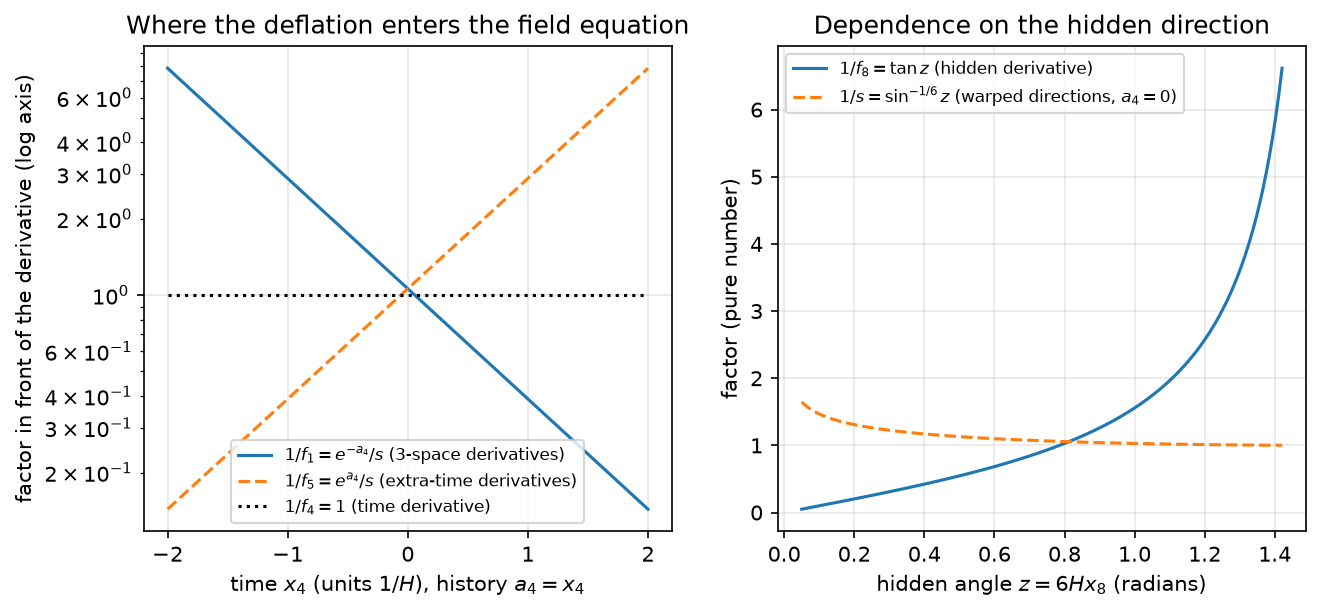

Figure 06a.9 saved as Revision/textbook/figures/06a_9_derivative_coefficients.png


In [21]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(10.0, 4.2))
coefficient = [sp.lambdify(X4_SYMBOL, (1 / fa).subs(history).subs(
    {H: 1, x8: sp.pi / 24})) for fa in f]
ax_left.semilogy(times, coefficient[0](times),
                 label="$1/f_1 = e^{-a_4}/s$ (3-space derivatives)")
ax_left.semilogy(times, coefficient[4](times), "--",
                 label="$1/f_5 = e^{a_4}/s$ (extra-time derivatives)")
ax_left.semilogy(times, np.ones_like(times), ":", color="black",
                 label="$1/f_4 = 1$ (time derivative)")
ax_left.set_xlabel("time $x_4$ (units $1/H$), history $a_4 = x_4$")
ax_left.set_ylabel("factor in front of the derivative (log axis)")
ax_left.set_title("Where the deflation enters the field equation")
ax_left.legend(fontsize=8)
zz = np.linspace(0.05, np.pi / 2 - 0.15, 300)
ax_right.plot(zz, np.tan(zz), label="$1/f_8 = \\tan z$ (hidden derivative)")
ax_right.plot(zz, np.sin(zz) ** (-1 / 6), "--",
              label="$1/s = \\sin^{-1/6} z$ (warped directions, $a_4 = 0$)")
ax_right.set_xlabel("hidden angle $z = 6Hx_8$ (radians)")
ax_right.set_ylabel("factor (pure number)")
ax_right.set_title("Dependence on the hidden direction")
ax_right.legend(fontsize=8)
save_figure(fig, "derivative_coefficients",
            "The factors $1/f_a$ in front of the derivatives in the Dirac operator "
            "$\\gamma^\\mu D_\\mu = \\sum_a f_a^{-1}\\gamma^{(a)}\\partial_a + "
            "3H\\gamma^{(x8)}$. Left: versus the time $x_4$ in units $1/H$ at $z = "
            "\\pi/4$ for the illustrative history $a_4 = x_4$, on a logarithmic axis: "
            "the 3-space factor $e^{-a_4}/s$ falls and the extra-time factor "
            "$e^{a_4}/s$ rises; this is how the deflation of the extra times enters "
            "the field equation. Right: versus the hidden angle $z$ in radians at "
            "$x_4 = 0$: the hidden factor $\\tan z$ and the factor $\\sin^{-1/6}z$ of "
            "the six warped directions.")

## 15. The negative control: extra times that INFLATE

Is the cancellation of the $a_4'$ terms an accident of the algebra, or does it come
from the deflation? The control answers this. The next cell repeats the whole
computation (Christoffel symbols, spin connection, spinor connection, curved
gammas) for a changed metric in which the extra times inflate like 3-space,
$g_{tt} = -e^{+2a_4}\sin^{1/3}z$ for $t = x5, x6, x7$, with vielbein factors
$e^{+a_4}s$. If the deflation is the reason, a term with $a_4'$ must survive. The
record of the lead's independent check finds $3a_4'\gamma^{(x4)}$; the cell checks
that it gets the same, and that the hidden term $3H\gamma^{(x8)}$ is unchanged.

In [22]:
f_control = [sp.exp(a4) * s] * 3 + [sp.Integer(1)] + [sp.exp(a4) * s] * 3 + [sp.cot(z)]
g_control = sp.diag(*[ETA[a] * f_control[a] ** 2 for a in range(8)])
e_control = sp.diag(*f_control)
Gam_control = christoffel(g_control, x)
omega_control = spin_connection(e_control, Gam_control, x, ETA)
Omega_control = spinor_connection(omega_control, S)
gup_control = curved_gammas(e_control, gamma)
slash_control = sum((gup_control[mu] * Omega_control[mu] for mu in range(8)), Z16)
alpha_control = sp.simplify(-(slash_control * gamma[3]).trace() / 16)
beta_control = sp.simplify((slash_control * gamma[7]).trace() / 16)
report("control: coefficient of gamma^(x4)", alpha_control)
report("control: coefficient of gamma^(x8)", beta_control)
lead = json.loads(repository_file(REPORT_LEAD).read_text(encoding="utf-8"))
detail = [c["detail"] for c in lead["checks"]
          if c["name"] == "negative_control_inflating_extra_times"][0]
check(matrix_is_zero(slash_control - alpha_control * gamma[3] - beta_control * gamma[7])
      and is_zero(alpha_control - 3 * sp.Derivative(a4, x4))
      and is_zero(beta_control - 3 * H)
      and "(3*Derivative(a4(x4), x4)) gamma^(x4)" in detail
      and record_passed(REPORT_LEAD, "negative_control_inflating_extra_times"),
      "control with inflating extra times: 3 a4' gamma^(x4) + 3 H gamma^(x8)",
      record=f"{REPORT_LEAD}, check negative_control_inflating_extra_times")

RESULT control: coefficient of gamma^(x4) = 3*Derivative(a4(x4), x4)
RESULT control: coefficient of gamma^(x8) = 3*H
PASS control with inflating extra times: 3 a4' gamma^(x4) + 3 H gamma^(x8)
     reproduces Revision/lead_checks/reports/emt-divergence-and-spin-connection.json,
    check negative_control_inflating_extra_times


The next cell draws the result of the control next to the author's case: the
coefficient of $\gamma^{(x4)}$ in $\gamma^\mu\Omega_\mu$ (left) and the coefficient
of $\gamma^{(x8)}$ (right) as functions of the rate $a_4'$ (with $H = 1$). With
deflating extra times (the author's metric) the left coefficient is zero for every
$a_4'$; with inflating extra times it is $3a_4'$, a straight line through the
origin. The hidden-direction coefficient $3H$ is the same in both cases: it comes
from $x8$, not from the time dependence.

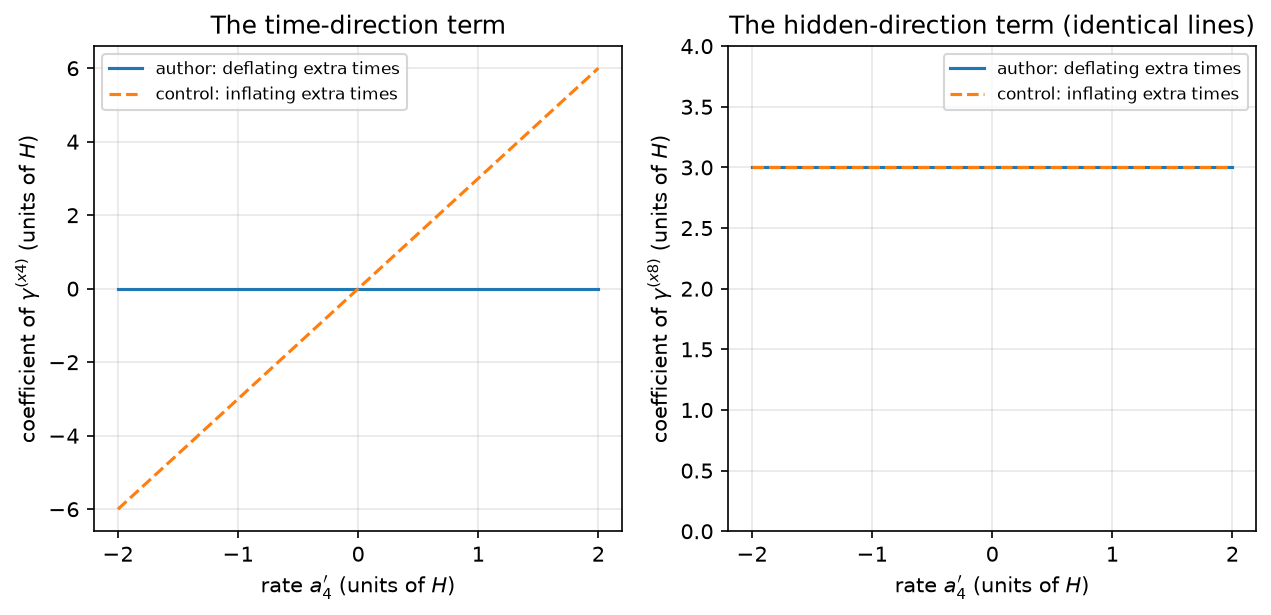

Figure 06a.10 saved as Revision/textbook/figures/06a_10_negative_control.png


In [23]:
rates = np.linspace(-2.0, 2.0, 81)  # values of a4'
rate_symbol = sp.Symbol("rate")
author_alpha = sp.lambdify(rate_symbol, sp.simplify(sum(
    a for a, _ in per_direction)).subs(sp.Derivative(a4, x4), rate_symbol))
control_alpha = sp.lambdify(rate_symbol, alpha_control.subs(
    sp.Derivative(a4, x4), rate_symbol))
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(10.0, 4.2))
ax_left.plot(rates, np.broadcast_to(author_alpha(rates), rates.shape),
             label="author: deflating extra times")
ax_left.plot(rates, np.broadcast_to(control_alpha(rates), rates.shape), "--",
             label="control: inflating extra times")
ax_left.set_xlabel("rate $a_4'$ (units of $H$)")
ax_left.set_ylabel("coefficient of $\\gamma^{(x4)}$ (units of $H$)")
ax_left.set_title("The time-direction term")
ax_left.legend(fontsize=8)
ax_right.plot(rates, np.full_like(rates, float(hidden.subs(H, 1))),
              label="author: deflating extra times")
ax_right.plot(rates, np.full_like(rates, float(beta_control.subs(H, 1))), "--",
              label="control: inflating extra times")
ax_right.set_ylim(0.0, 4.0)
ax_right.set_xlabel("rate $a_4'$ (units of $H$)")
ax_right.set_ylabel("coefficient of $\\gamma^{(x8)}$ (units of $H$)")
ax_right.set_title("The hidden-direction term (identical lines)")
ax_right.legend(fontsize=8)
save_figure(fig, "negative_control",
            "The negative control. Left: the coefficient of $\\gamma^{(x4)}$ in "
            "$\\gamma^\\mu\\Omega_\\mu$ versus the rate $a_4'$, both in units of $H = "
            "1$, for the author's metric with deflating extra times (solid, zero for "
            "every rate) and for a control metric with inflating extra times (dashed, "
            "the line $3a_4'$). Right: the coefficient of $\\gamma^{(x8)}$, $3H$ in "
            "both cases (the two lines lie on top of each other). The cancellation "
            "of the time-direction terms is caused by the deflation.")

## 16. The last checks

Most results of this notebook are recorded three times in the Revision record, by
three verifiers that share no code: the sympy checker (report
`python-field-theory.json`), the WolframScript checker (`wolfram-field-theory.json`)
and the lead's independent check (`emt-divergence-and-spin-connection.json`). Each
PASS line above names one of them. The last cell lists every check of these three
reports that states a result reproduced here and checks that each is recorded as
passed (so the record this notebook reproduces is itself a passing record). Then it
checks that all ten figure files exist in the folder Revision/textbook/figures, and
prints the number of checks that passed.

In [24]:
cited = {
    REPORT_PY: ["clifford_relations", "gammas_real", "metric_from_vielbein_equals_SPEC",
                "sqrt_det_g_equals_cos_z", "vielbein_postulate",
                "spin_connection_antisymmetric", "nontriviality_Omega_zero_iff_flat",
                "Omega_x4_and_Omega_x8_vanish", "covariant_constancy_D_mu_gamma_nu",
                "time_terms_cancel_hidden_term_survives",
                "gamma_mu_Omega_mu_equals_3H_gamma_x8",
                "anticommutator_gamma_Omega_vanishes", "divergence_of_sqrtg_gamma"],
    REPORT_WL: ["metric_is_the_authors", "sqrt_det_g_is_cos_z", "christoffel_count",
                "vielbein_postulate", "omega_antisymmetric", "omega_components",
                "Omega_components", "S_rotates_gamma_with_omega",
                "gamma_covariantly_constant", "gammaOmega_equals_3H_gamma_x8",
                "gammaOmega_x4_terms_cancel", "gammaOmega_divergence_form",
                "Dirac_operator_explicit_C", "Dirac_operator_explicit_G",
                "nontriviality_1_dirac16complex", "nontriviality_2_dirac16complex00",
                "Omega_vanishes_iff_a4prime_and_H_vanish", "block_form"],
    REPORT_LEAD: ["vielbein_reproduces_metric", "gamma_Omega_equals_3H_gamma8",
                  "gamma_Omega_divergence_formula",
                  "negative_control_inflating_extra_times"],
}
count = sum(len(names) for names in cited.values())
check(all(record_passed(path, name) for path, names in cited.items()
          for name in names),
      f"the {count} cited record checks are recorded as passed")
expected = [f"06a_{k}_{name}.png" for k, name in enumerate([
    "polar_frame_and_spin_rotation", "vielbein_factors", "christoffel_pattern",
    "omega_heat_maps", "spinor_connection_heat_maps", "gamma_omega_per_direction",
    "gamma_omega_cancellation", "divergence_form", "derivative_coefficients",
    "negative_control"], 1)]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in expected),
      "all ten figure files exist")
all_checks_passed()

PASS the 35 cited record checks are recorded as passed
PASS all ten figure files exist
ALL 34 CHECKS PASSED (notebook 06a)


## 17. What this notebook showed

- In the flat plane in polar coordinates the spin connection is not zero
  ($\omega_{\varphi 01} = -1$, $\gamma^\mu\Omega_\mu = \sigma_1/(2r)$), but its
  curvature is zero and a spinor rotation removes it: in flat space the spin
  connection only records how the chosen frame turns.
- For the author's metric the diagonal vielbein $f = (e^{a_4}s\ (\times 3),\ 1,\
  e^{-a_4}s\ (\times 3),\ \cot z)$ gives the metric back, and $\sqrt{|\det g|} =
  \cos z$ does not depend on the time (PROVED, exact; reproduces the record).
- The metric has 25 independent nonzero Christoffel symbols, and the canonical spin
  connection has 12 independent nonzero components $\omega_{\mu ab}$, each equal to
  $a_4'$ or $H$ times a factor that never vanishes; the vielbein postulate (512
  equations), the antisymmetry and the covariant constancy of the gammas (64 matrix
  equations) hold exactly (PROVED; reproduces the record).
- $\gamma^\mu\Omega_\mu = 3H\gamma^{(x8)}$ exactly, for every $H > 0$ and every
  function $a_4(x_4)$ (PROVED; reproduces the Python, Wolfram and lead records):
  the time-direction terms $+\frac32 a_4'$ of the three inflating directions and
  $-\frac32 a_4'$ of the three deflating extra times cancel, and the six hidden
  terms $\frac12 H$ add up to $3H$. The reason is the divergence form: the
  density $\sqrt{|g|}\,e_{(x4)}{}^{x4} = \cos z$ does not change with the time.
- The Dirac operator is $\sum_a f_a^{-1}\gamma^{(a)}\partial_a + 3H\gamma^{(x8)}$;
  all 16 component equations equal the record. The deflation enters the field
  equation through the factors $e^{\mp a_4}$ in front of the derivatives, not
  through $\gamma^\mu\Omega_\mu$.
- NEGATIVE CONTROL: with inflating extra times the term $3a_4'\gamma^{(x4)}$
  survives (reproduces the lead's record): the cancellation is caused by the
  deflation.
- Scope (stated by the record and shown in Notebook 06b): the value
  $3H\gamma^{(x8)}$ belongs to the diagonal vielbein; it changes in a boosted
  vielbein and is removed by the rescaling $\Psi = \sin^{-1/2}(z)\,\chi$, while the
  curvature of the metric can be removed by nothing.